# Introduction to PyTorch

**From `torch.tensor([1.0])` to a convolutional network that reads photographs** · ~3.5 hours

---

## What this class is

Every deep-learning framework — PyTorch, TensorFlow, JAX — exists to do exactly **four**
things for you. If you understand those four things, you understand the framework, and
everything else is API surface you can look up.

| # | The job | PyTorch's answer |
|---|---------|------------------|
| 1 | Hold numbers, fast, on whatever hardware you have | **`torch.Tensor`** — a NumPy array on the GPU |
| 2 | Work out *which way to nudge* every number to reduce the error | **autograd** (`.backward()` → `.grad`) |
| 3 | Bundle millions of those numbers into reusable layers | **`torch.nn.Module`** |
| 4 | Feed data in shuffled, batched, and on time | **`Dataset` + `DataLoader`** |

Parts 1–4 take those one at a time. Parts 5–8 are the same four things wired into a loop,
pointed at real images.

## The spine of the day

We train the *same* network twice — once on an easy dataset, once on a hard one — watch it
fall over, and then fix it with a convolutional network. That failure in the middle is the
whole point of the class: it is the reason CNNs exist.

```text
     ┌───────────────────────────────────────────────────────────┐
     │  THE FOUR THINGS PYTORCH IS                               │
     │                                                           │
     │   P1  TENSOR      a NumPy array that can use a GPU        │
     │   P2  AUTOGRAD    .backward() fills .grad                 │
     │   P3  nn.Module   layers, loss function, optimizer        │
     │   P4  DataLoader  hands you shuffled batches              │
     └───────────────────────────┬───────────────────────────────┘
                                 │
              everything below is those four in a `for` loop
                                 │
      ┌──────────────────────────┴──────────────────────────┐
      ▼                                                     ▼
 P5  MNIST  28×28 grey · 10 classes            P6  CIFAR-100  32×32 colour · 100 classes
     ┌───────────────────┐                         ┌───────────────────┐
     │  MLP  →   ~98 %   │                         │  MLP  →   ~ 22 %  │   ← the SAME model
     │  "that was easy"  │                         │  "…oh."           │      falls apart
     └───────────────────┘                         └─────────┬─────────┘
                                                             │  why?
                                                             ▼
                                              P7  CNN on CIFAR-100  →  ~55 %
                                                  FEWER parameters, DOUBLE the score
                                                             │
                                                             ▼
                                              P8  save → load → predict one image
```

## Who this is for

You can write Python and you know, roughly, that a neural network is layers of weights
trained by gradient descent. You have never written PyTorch, or you have copy-pasted it
without knowing which lines matter. By the end you will be able to read any training script
on GitHub and know what every line is for.

## What we deliberately skip

A full tour of the tensor API (broadcasting rules, `view` vs `reshape`, stride tricks),
transfer learning, data augmentation, learning-rate schedulers, distributed training,
`torch.compile`, custom autograd functions. All useful, none of them necessary to
*understand PyTorch*. Come back to them once today's four things are automatic — and look
the tensor operations up the day you need one, the way you did with NumPy.


```text
●P0 SETUP → P1 tensor vs numpy → P2 autograd → P3 nn.Module → P4 dataloader →
P5 mnist+mlp → P6 cifar+mlp → P7 cifar+cnn → P8 save+predict
```

# Part 0 — Setup

Three things every PyTorch script starts with: **imports**, a **seed** so results repeat,
and a **device** so we know where the maths happens.


### Install

Skip this if your environment already has PyTorch. On Colab, PyTorch is preinstalled and
only `ipython-autotime` is missing.

`ipython-autotime` prints the wall-clock time under every cell — useful in a class, because
"how long does training actually take" is a real question and guessing is no fun.


In [1]:
# !pip -q install torch torchvision scikit-learn matplotlib tqdm ipython-autotime

In [2]:
%load_ext autotime

time: 85.7 µs (started: 2026-08-20 16:58:25 +05:30)


### Imports

A tour of the namespace, because these five imports are ~90% of all PyTorch code you will
ever read:

| Import | What lives in it |
|---|---|
| `torch` | tensors and tensor maths — `torch.randn`, `torch.save`, `torch.no_grad` |
| `torch.nn` as `nn` | **layers and losses as objects** — `nn.Linear`, `nn.Conv2d`, `nn.CrossEntropyLoss` |
| `torch.nn.functional` as `F` | the same maths as **plain functions** — `F.relu`, `F.softmax` |
| `torch.optim` as `optim` | the update rules — `optim.SGD`, `optim.Adam` |
| `torch.utils.data` | `Dataset` and `DataLoader` — the batching machinery |

**`nn` vs `F`** is the one that confuses everybody. Same maths, different packaging:
things with **learnable weights** must be `nn.` objects (they need somewhere to store the
weights); things with **no weights** — ReLU, softmax, pooling — can be either. `nn.Linear`
has weights, so it must be a layer. `F.relu` has none, so it can be a function call inside
`forward`.


In [3]:
import random, os, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn                      # layers & losses as objects (they hold weights)
import torch.nn.functional as F            # the same maths as stateless functions
import torch.optim as optim                # SGD, Adam, ...
from torch.utils.data import DataLoader    # turns a Dataset into shuffled batches
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

print("torch      :", torch.__version__)
import torchvision; print("torchvision:", torchvision.__version__)

torch      : 2.10.0
torchvision: 0.25.0
time: 2.75 s (started: 2026-08-20 16:58:25 +05:30)


### Seeding

Neural networks start from *random* weights and are fed data in a *random* order. Run the
same script twice and you get two different numbers. That is fine in production and
maddening in a classroom, so we pin every random number generator we can reach.

`set_seed` touches four separate generators, because PyTorch is not the only thing rolling
dice: Python's `random` shuffles, NumPy's generator is used by many transforms, and CUDA
keeps its own state per GPU.

One honest caveat: **seeding does not guarantee bit-identical results across machines.**
Different hardware (CPU vs MPS vs CUDA), different library versions, and non-deterministic
GPU kernels can all shift the last decimal place. Your accuracy numbers should land within
a few tenths of a percent of the ones committed here — not exactly on them.


In [4]:
def set_seed(seed=42):
    random.seed(seed)                          # Python's own RNG
    np.random.seed(seed)                       # NumPy's RNG
    torch.manual_seed(seed)                    # PyTorch CPU + MPS
    torch.cuda.manual_seed_all(seed)           # every CUDA GPU (no-op if there is none)
    torch.backends.cudnn.deterministic = True  # pick reproducible cuDNN kernels...
    torch.backends.cudnn.benchmark = False     # ...instead of the fastest-found ones

set_seed(42)
print("seeded")

seeded
time: 1.73 ms (started: 2026-08-20 16:58:28 +05:30)


### Device

A tensor lives *somewhere*: in normal RAM (`cpu`), in an NVIDIA GPU's memory (`cuda`), or
in Apple Silicon's unified memory (`mps`). Maths only happens between tensors on the **same**
device — mixing them is one of the two errors you are guaranteed to hit today.

The idiom below picks the best available backend and stores it in one variable. From here
on, everything that needs to be fast gets `.to(device)` and we never hard-code `"cuda"`
anywhere — which is why this notebook runs unchanged on a Mac, on Colab, and on a CPU-only
box.


In [5]:
if torch.backends.mps.is_available():          # Apple Silicon GPU
    device = torch.device("mps")
elif torch.cuda.is_available():                # NVIDIA GPU
    device = torch.device("cuda")
else:
    device = torch.device("cpu")               # always works, just slower

print("Device:", device)

Device: mps
time: 17.2 ms (started: 2026-08-20 16:58:28 +05:30)


### Where the data lives

Both datasets are read from a local `data/` folder next to this notebook. `download=True`
means torchvision fetches them the first time and then reuses the cache — so re-running
this notebook costs nothing.

- **MNIST** — 70,000 handwritten digits, 28×28, greyscale. ~11 MB.
- **CIFAR-100** — 60,000 photographs, 32×32, colour, 100 classes. ~170 MB.


In [6]:
DATA_ROOT = Path("data")           # torchvision creates/uses ./data/MNIST and ./data/cifar-100-python
DATA_ROOT.mkdir(exist_ok=True)
print("data root:", DATA_ROOT.resolve())

data root: /Users/shivam13juna/Documents/scaler/GEN_AI_REF/Intro_To_PyTorch/data
time: 486 µs (started: 2026-08-20 16:58:28 +05:30)


```text
P0 setup → ●P1 TENSOR VS NUMPY → P2 autograd → P3 nn.Module → P4 dataloader →
P5 mnist+mlp → P6 cifar+mlp → P7 cifar+cnn → P8 save+predict
```

# Part 1 — A tensor is a NumPy array with two extra powers

Good news: you already know most of this.

A **tensor** is an n-dimensional array of numbers — exactly the same idea as `np.ndarray`.
Same shapes, same indexing, same `+ - * /`, same `.sum()` and `.mean()`. If you can write
NumPy, you can read tensor code today without learning a new mental model.

So why does PyTorch have its own array type instead of just using NumPy? Two reasons, and
they are the entire content of this Part:

| | NumPy | PyTorch tensor |
|---|---|---|
| n-dim array of numbers | ✅ | ✅ |
| runs on the **GPU** | ❌ CPU only | ✅ `.to(device)` |
| **remembers what was done to it**, so it can compute gradients | ❌ | ✅ `requires_grad=True` |

That second row is the one that matters. It is why this notebook exists, and Part 2 is
entirely about it.

**We are not doing a tour of the tensor API.** You will pick that up by using it. This Part
is five short cells: make one, prove it behaves like NumPy, then meet the two differences.


### Making one

`torch.tensor(...)` wraps data you already have. `torch.randn(...)` and friends invent new
data of a given shape — you will use `randn` for fake test inputs constantly.


In [7]:
a = torch.tensor([1.0, 2.0, 3.0])       # from a Python list
b = torch.zeros(2, 3)                   # shape (2, 3), all zeros
c = torch.randn(2, 3)                   # shape (2, 3), random normal — the one you'll use most

print("a       :", a)
print("a.shape :", a.shape, "  <- like np.shape")
print("a.dtype :", a.dtype, " <- float32, NOT float64 like NumPy's default")
print()
print("c =\n", c)

a       : tensor([1., 2., 3.])
a.shape : torch.Size([3])   <- like np.shape
a.dtype : torch.float32  <- float32, NOT float64 like NumPy's default

c =
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])
time: 1.85 ms (started: 2026-08-20 16:58:28 +05:30)


### Proof it is the same thing as NumPy

Same operations, same numbers. `torch.from_numpy()` and `.numpy()` convert both ways for
free — they do not even copy the data, the two objects share the same memory.

One wrinkle worth seeing now, because it bites people later: NumPy defaults to **float64**,
PyTorch to **float32**, and `from_numpy` keeps whatever NumPy gave it. Feed a float64 tensor
to a model and you get a dtype error. The fix is always `.float()`.


In [8]:
arr = np.array([1.0, 2.0, 3.0])
ten = torch.from_numpy(arr)                    # numpy -> torch

print("numpy :", arr * 2 + 1, "  mean =", arr.mean())
print("torch :", ten * 2 + 1, "  mean =", ten.mean().item())
print("       ^ same numbers.")

print("\nand back again:", ten.numpy(), type(ten.numpy()))

print("\ndtype came along for the ride:", ten.dtype, "  <- NumPy's default, not PyTorch's")
print("models want float32, so you convert:", ten.float().dtype)

numpy : [3. 5. 7.]   mean = 2.0
torch : tensor([3., 5., 7.], dtype=torch.float64)   mean = 2.0
       ^ same numbers.

and back again: [1. 2. 3.] <class 'numpy.ndarray'>

dtype came along for the ride: torch.float64   <- NumPy's default, not PyTorch's
models want float32, so you convert: torch.float32
time: 1.11 ms (started: 2026-08-20 16:58:28 +05:30)


### Difference 1 — it can move to the GPU

`.to(device)` returns a **new tensor on that device**; the original stays where it was.
NumPy simply cannot do this — that is the whole reason `torch.Tensor` exists rather than
PyTorch borrowing `ndarray`.

Two things to notice below, because you will hit both today:

1. `x.to(device)` does **not** modify `x`. You must reassign: `x = x.to(device)`.
2. Maths between a CPU tensor and a GPU tensor **raises**. Both operands have to be in the
   same place. This is the single most common PyTorch error message in existence.


In [9]:
cpu_tensor = torch.randn(3)
gpu_tensor = cpu_tensor.to(device)               # a NEW tensor, on the accelerator

print("original stays put :", cpu_tensor.device)
print("copy moved to      :", gpu_tensor.device)

try:
    cpu_tensor + gpu_tensor
except Exception as err:
    print("\nmixing devices ->", type(err).__name__, "-", str(err)[:110], "...")

print("\nfix: move one to meet the other ->", (cpu_tensor.to(device) + gpu_tensor).device)

original stays put : cpu
copy moved to      : mps:0

mixing devices -> RuntimeError - Expected all tensors to be on the same device, but found at least two devices, mps:0 and cpu! ...

fix: move one to meet the other -> mps:0
time: 23.3 ms (started: 2026-08-20 16:58:28 +05:30)


### Difference 2 — it remembers what was done to it

Ask for `requires_grad=True` and the tensor starts **recording**. Every operation you apply
gets logged, so PyTorch can later work backwards and tell you how each input affected the
result.

Watch the `grad_fn` appear on the result below. NumPy has no equivalent of that field, and
building it yourself is genuinely hard — which is exactly why we use a framework.

This is a 30-second preview. Part 2 is the real explanation.


In [10]:
w = torch.tensor(5.0, requires_grad=True)     # "I will want a gradient for this"
out = (w - 3) ** 2                            # do some maths

print("out       :", out)
print("out.grad_fn:", out.grad_fn, " <- a receipt: 'I was made by a power operation'")

out.backward()                                # walk the recording backwards
print("w.grad    :", w.grad.item(), " <- d(out)/dw = 2*(5-3) = 4    ✓ school calculus")

out       : tensor(4., grad_fn=<PowBackward0>)
out.grad_fn: <PowBackward0 object at 0x10854c190>  <- a receipt: 'I was made by a power operation'
w.grad    : 4.0  <- d(out)/dw = 2*(5-3) = 4    ✓ school calculus
time: 1.21 ms (started: 2026-08-20 16:58:28 +05:30)


### The five tensor operations you will actually meet

That is the end of the theory. But five specific operations show up in the code from Part 5
onwards, and it is nicer to see them once here than to be ambushed by them mid-training-loop.
Read the table, run the cell, and move on — you do not need to memorise anything.

| Operation | What it does | Where you will see it |
|---|---|---|
| `x.view(batch, -1)` | flatten each sample to a row; `-1` = "work the rest out yourself" | first line of every `MLP.forward` |
| `scores.argmax(dim=1)` | index of the largest score per row → **the prediction** | every accuracy calculation |
| `float32` vs `int64` | data and weights are `float32`; **class labels must be `int64`** | the #2 most common error message |
| `.item()` | pull a single number out of a 1-element tensor as a Python float | `loss.item()`, every training loop |
| `.detach().cpu().numpy()` | hand a tensor to matplotlib: drop the recording, leave the GPU, convert | every plot we draw |


In [11]:
batch = torch.randn(4, 1, 28, 28)            # 4 MNIST-shaped images

flat = batch.view(4, -1)                     # 1. flatten: (4,1,28,28) -> (4, 784)
print("view   :", tuple(batch.shape), "->", tuple(flat.shape), " (1*28*28 = 784)")

scores = torch.tensor([[0.1, 8.2, 0.3],      # 2. argmax: 3 samples, 3 classes each
                       [5.0, 0.2, 0.1],
                       [0.4, 0.3, 9.9]])
print("argmax :", scores.argmax(dim=1), " <- predicted class of each row")

labels = torch.tensor([1, 0, 0])             # 3. dtypes — the true class of each row
print("dtypes : data", batch.dtype, "| labels", labels.dtype, "<- int64, as the loss requires")

acc = (scores.argmax(dim=1) == labels).float().mean()   # 2 of 3 rows match -> 0.667
print("item   : %.3f" % acc.item(), " <- a Python float, not a tensor")

print("numpy  :", flat[0, :4].detach().cpu().numpy(), " <- ready for matplotlib")

view   : (4, 1, 28, 28) -> (4, 784)  (1*28*28 = 784)
argmax : tensor([1, 0, 2])  <- predicted class of each row
dtypes : data torch.float32 | labels torch.int64 <- int64, as the loss requires
item   : 0.667  <- a Python float, not a tensor
numpy  : [-0.75813115  1.0783176   0.8008005   1.6806206 ]  <- ready for matplotlib
time: 1.12 ms (started: 2026-08-20 16:58:28 +05:30)


---

### Part 1 recap

- A tensor **is** a NumPy array. Same shapes, same maths, converts back and forth for free.
- Difference 1: it can live on the GPU — `.to(device)`. Both operands must be on the same one.
- Difference 2: with `requires_grad=True` it records what happens to it, so gradients can be
  computed automatically. **This is the only genuinely new idea in PyTorch.**
- Five operations to recognise: `view(batch, -1)`, `argmax(dim=1)`, `float32`/`int64`,
  `.item()`, `.detach().cpu().numpy()`.

Anything else about tensors, you can look up the day you need it. On to the part that matters.


```text
P0 setup → P1 tensor vs numpy → ●P2 AUTOGRAD → P3 nn.Module → P4 dataloader →
P5 mnist+mlp → P6 cifar+mlp → P7 cifar+cnn → P8 save+predict
```

# Part 2 — Autograd: the part that makes it a *deep-learning* library

Everything in Part 1 was NumPy with a GPU. **This** is the part that is actually hard to
build yourself, and it is the reason PyTorch exists.

Training a network means: *"the loss is 2.31 — which way should I nudge each of my 400,000
weights to make it smaller?"* The answer is the derivative of the loss with respect to each
weight. Doing that by hand for 400,000 weights through 8 layers is not happening.

So PyTorch does it for you. As you compute, it silently records **every operation** in a
graph. When you call `.backward()` it walks that graph backwards, applying the chain rule,
and deposits the derivative into each input's **`.grad`**. That is the whole idea.

```text
   FORWARD  (you write this)                BACKWARD  (PyTorch writes this)

   x ──▶ (x-3) ──▶ (·)² ──▶ + ──▶ y         x.grad ◀── 2(x-3) ◀── 1 ◀── dy/dy = 1
   z ─────────────────────▶┘                z.grad ◀──────── 1 ◀──┘

   torch RECORDS each arrow                 .backward() REPLAYS them in reverse,
   as it happens                            multiplying derivatives (chain rule)
```

We will use a two-line equation rather than a neural network, because the mechanism is
identical and you can check the answer with school calculus.


### `requires_grad` — opting a tensor in

By default tensors are *not* tracked; recording a graph costs memory and time, and most
tensors (your input images, for instance) never need a gradient. Setting
`requires_grad=True` says **"I will want d(something)/d(this)"**.

In a real network you never write this by hand — every weight inside an `nn.Module` gets it
automatically. Here we do it manually so you can see the machinery.


In [12]:
x = torch.tensor(5.0, requires_grad=True)      # we want dy/dx
z = torch.tensor(2.0, requires_grad=True)      # ...and dy/dz

print("x =", x)
print("x.requires_grad :", x.requires_grad)
print("x.grad          :", x.grad, "  <- None: nothing has been computed backwards yet")
print("x.item()        :", x.item(), " <- the raw Python float")

x = tensor(5., requires_grad=True)
x.requires_grad : True
x.grad          : None   <- None: nothing has been computed backwards yet
x.item()        : 5.0  <- the raw Python float
time: 680 µs (started: 2026-08-20 16:58:28 +05:30)


### The forward pass builds a graph

Compute something. Notice what comes back: not just a number, but a tensor carrying a
**`grad_fn`** — a pointer to the operation that produced it. Follow those pointers backwards
and you have the whole computational history.

$$y = (x - 3)^2 + z$$


In [13]:
y = (x - 3)**2 + z

print("y        =", y.item(), "   ( (5-3)^2 + 2 = 4 + 2 = 6 )")
print("y        =", y)
print("y.grad_fn:", y.grad_fn, " <- the LAST op was an addition")
print("its input:", y.grad_fn.next_functions, " <- ...which came from a power and from z")

y        = 6.0    ( (5-3)^2 + 2 = 4 + 2 = 6 )
y        = tensor(6., grad_fn=<AddBackward0>)
y.grad_fn: <AddBackward0 object at 0x10854dff0>  <- the LAST op was an addition
its input: ((<PowBackward0 object at 0x107fb42e0>, 0), (<AccumulateGrad object at 0x12cf572b0>, 0))  <- ...which came from a power and from z
time: 693 µs (started: 2026-08-20 16:58:28 +05:30)


### `.backward()` fills in `.grad`

One call walks the graph in reverse and writes the derivative into every leaf tensor that
asked for one.

Check it by hand:

$$\frac{\partial y}{\partial x} = 2(x-3) = 2(5-3) = \mathbf{4}
\qquad
\frac{\partial y}{\partial z} = \mathbf{1}$$


In [14]:
y.backward()          # walk the graph backwards, apply the chain rule

print("x.grad =", x.grad.item(), "  (hand-derived: 2*(5-3) = 4)   ✓")
print("z.grad =", z.grad.item(), "  (hand-derived: 1)             ✓")

x.grad = 4.0   (hand-derived: 2*(5-3) = 4)   ✓
z.grad = 1.0   (hand-derived: 1)             ✓
time: 325 µs (started: 2026-08-20 16:58:28 +05:30)


**Read those two numbers as instructions.** `x.grad = 4` means *"increasing `x` by a
little increases `y` by about 4× as much."* If your goal is to make `y` **smaller**, you move
`x` in the **opposite** direction to its gradient. That single sentence is gradient descent,
and we will use it literally in a moment.


### `.backward()` only works on scalars

The graph is walked from *one* number backwards. Ask a vector to go backward and PyTorch
does not know what you want the derivative *of*. This is exactly why every training loop
ends with a **loss** — a single number that summarises the whole batch. `.mean()` is usually
how you get there.


In [15]:
v = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
out = v * 2                                     # a vector, not a scalar

try:
    out.backward()
except Exception as err:
    print("vector backward ->", type(err).__name__, "-", str(err)[:75], "...")

out.mean().backward()                           # reduce to a scalar first
print("\nv.grad after .mean().backward():", v.grad, "  (d/dv of (2v1+2v2+2v3)/3 = 2/3 each)")

vector backward -> RuntimeError - grad can be implicitly created only for scalar outputs ...

v.grad after .mean().backward(): tensor([0.6667, 0.6667, 0.6667])   (d/dv of (2v1+2v2+2v3)/3 = 2/3 each)
time: 780 µs (started: 2026-08-20 16:58:28 +05:30)


### The gotcha: gradients **accumulate**

`.backward()` *adds* to `.grad` — it does not overwrite it. Call backward twice without
clearing and you get double the gradient, your update is twice as big as intended, and
training quietly diverges with no error message.

This design is deliberate (it lets you sum gradients over several mini-batches before
updating), but it means **you must clear the gradients yourself every iteration.** That is
what `optimizer.zero_grad()` will be doing in every training loop from Part 5 on — now you
know why that line is there.


In [16]:
x = torch.tensor(5.0, requires_grad=True)

y1 = (x - 3)**2; y1.backward()
print("after 1st backward :", x.grad.item(), "  <- correct")

y2 = (x - 3)**2; y2.backward()
print("after 2nd backward :", x.grad.item(), "  <- ACCUMULATED, not recomputed (4 + 4)")

x.grad.zero_()                                  # the trailing _ means 'in place'
print("after zero_()      :", x.grad.item())

y3 = (x - 3)**2; y3.backward()
print("after 3rd backward :", x.grad.item(), "  <- correct again")

after 1st backward : 4.0   <- correct
after 2nd backward : 8.0   <- ACCUMULATED, not recomputed (4 + 4)
after zero_()      : 0.0
after 3rd backward : 4.0   <- correct again
time: 855 µs (started: 2026-08-20 16:58:28 +05:30)


### `torch.no_grad()` — switching the recorder off

Building the graph costs memory and time. During **evaluation** you only want predictions,
never gradients, so you wrap the code in `torch.no_grad()`. Tensors produced inside come out
with no `grad_fn`, use noticeably less memory, and run faster.

Every evaluation block in this notebook is wrapped in it. Forget it and your test loop will
be slow and may run out of memory on a large model.


In [17]:
x = torch.tensor(5.0, requires_grad=True)

with torch.no_grad():
    y = (x - 3)**2

print("y        =", y.item())
print("y.grad_fn:", y.grad_fn, " <- None: nothing was recorded")

try:
    y.backward()
except Exception as err:
    print("\nbackward inside no_grad ->", type(err).__name__, "-", str(err)[:70], "...")

y        = 4.0
y.grad_fn: None  <- None: nothing was recorded

backward inside no_grad -> RuntimeError - element 0 of tensors does not require grad and does not have a grad_fn ...
time: 467 µs (started: 2026-08-20 16:58:28 +05:30)


`.detach()` is the same idea for a single tensor: it gives you a copy that shares the
data but has been cut out of the graph. That is the `detach` in
`.detach().cpu().numpy()` — you cannot export a tensor to NumPy while autograd is still
holding on to it.


In [18]:
a = torch.tensor([2.0], requires_grad=True)
b = a * 3
print("b requires grad?         :", b.requires_grad)
print("b.detach() requires grad?:", b.detach().requires_grad)

try:
    b.numpy()
except Exception as err:
    print("\nb.numpy() ->", type(err).__name__, "-", str(err)[:95], "...")
print("b.detach().numpy() ->", b.detach().numpy())

b requires grad?         : True
b.detach() requires grad?: False

b.numpy() -> RuntimeError - Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead. ...
b.detach().numpy() -> [6.]
time: 583 µs (started: 2026-08-20 16:58:28 +05:30)


### The payoff: this *is* training

We now have every ingredient. Let us find the value of `x` that minimises
$y = (x-3)^2$ — without solving anything, using only `.grad`.

The recipe, repeated 30 times:

1. compute `y` from the current `x`  → **forward pass**
2. `y.backward()`                     → **fill `x.grad`**
3. `x -= lr * x.grad`                 → **step downhill**
4. `x.grad.zero_()`                   → **clear, because gradients accumulate**

Those four lines are the *entire* training loop of every neural network in this notebook.
The only thing that changes later is that `x` becomes 400,000 weights and `y` becomes a loss
computed over a batch of images — `nn.Module` will hold the weights and `optim` will do
step 3 and 4 for us. The mechanism does not change at all.


In [19]:
x = torch.tensor(10.0, requires_grad=True)      # start far from the answer
lr = 0.1                                       # learning rate: how big a step to take
history = []

for step in range(30):
    y = (x - 3)**2                             # 1. forward
    y.backward()                               # 2. fill x.grad

    with torch.no_grad():                      # 3. step downhill.  no_grad because
        x -= lr * x.grad                       #    updating weights is not part of the model

    history.append((x.item(), y.item()))
    x.grad.zero_()                             # 4. clear for the next round

    if step % 5 == 0 or step == 29:
        print(f"step {step:>2} | x = {x.item():6.3f} | y = {y.item():8.4f}")

print(f"\nconverged to x = {x.item():.4f}  (the true minimum of (x-3)^2 is x = 3)")

step  0 | x =  8.600 | y =  49.0000
step  5 | x =  4.835 | y =   5.2613
step 10 | x =  3.601 | y =   0.5649
step 15 | x =  3.197 | y =   0.0607
step 20 | x =  3.065 | y =   0.0065
step 25 | x =  3.021 | y =   0.0007
step 29 | x =  3.009 | y =   0.0001

converged to x = 3.0087  (the true minimum of (x-3)^2 is x = 3)
time: 1.43 ms (started: 2026-08-20 16:58:28 +05:30)


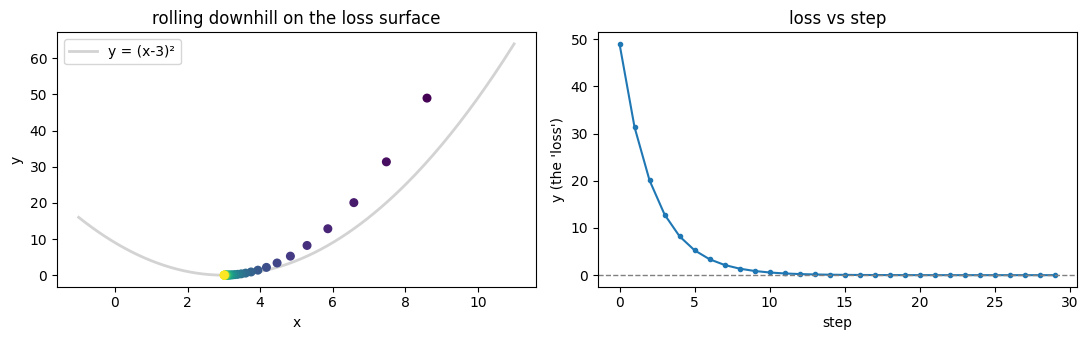

time: 96.5 ms (started: 2026-08-20 16:58:28 +05:30)


In [20]:
xs = [h[0] for h in history]
ys = [h[1] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

curve = torch.linspace(-1, 11, 200)
ax1.plot(curve, (curve - 3)**2, color="lightgray", lw=2, label="y = (x-3)²")
ax1.scatter(xs, ys, c=range(len(xs)), cmap="viridis", s=30, zorder=3)
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_title("rolling downhill on the loss surface")
ax1.legend()

ax2.plot(ys, marker="o", ms=3)
ax2.axhline(0, ls="--", c="gray", lw=1)
ax2.set_xlabel("step"); ax2.set_ylabel("y (the 'loss')"); ax2.set_title("loss vs step")
plt.tight_layout(); plt.show()

That right-hand plot is a **loss curve** — the same plot we will draw for every model
today. Steep at first, flattening as the gradient shrinks near the minimum.

Try changing `lr` and re-running: `0.01` crawls and never arrives in 30 steps, `1.1`
overshoots and explodes to infinity. Choosing a learning rate is the single most important
hyperparameter decision in deep learning, and this toy is exactly why.


### The same loop, written the way you actually write it

Two of those four lines were pure bookkeeping:

```python
with torch.no_grad():
    x -= lr * x.grad        # apply the update rule
x.grad.zero_()              # clear for next time
```

Nobody writes those by hand. They are identical for every parameter of every model, so
PyTorch packages them into an **optimizer**. You hand it the list of tensors to look after,
and it does the updating and the clearing for you:

```python
optimizer = optim.SGD([x], lr=0.1)    # "look after this list of tensors"
optimizer.zero_grad()                 # replaces x.grad.zero_()
optimizer.step()                      # replaces x -= lr * x.grad
```

Here is the *exact same problem* again, same learning rate, same 30 steps — only the
bookkeeping changed. Compare the two loops side by side and check that the final number is
identical.


In [21]:
x = torch.tensor(10.0, requires_grad=True)      # same starting point as before
optimizer = optim.SGD([x], lr=0.1)             # <- hand the tensor(s) to the optimizer

for step in range(30):
    y = (x - 3)**2                             # 1. forward
    optimizer.zero_grad()                      # 2. clear old gradients   (was: x.grad.zero_())
    y.backward()                               # 3. fill x.grad
    optimizer.step()                           # 4. update                (was: x -= lr * x.grad)

    if step % 5 == 0 or step == 29:
        print(f"step {step:>2} | x = {x.item():6.3f} | y = {y.item():8.4f}")

print(f"\nconverged to x = {x.item():.4f}   <- identical to the hand-written loop above")

step  0 | x =  8.600 | y =  49.0000
step  5 | x =  4.835 | y =   5.2613
step 10 | x =  3.601 | y =   0.5649
step 15 | x =  3.197 | y =   0.0607
step 20 | x =  3.065 | y =   0.0065
step 25 | x =  3.021 | y =   0.0007
step 29 | x =  3.009 | y =   0.0001

converged to x = 3.0087   <- identical to the hand-written loop above
time: 2.26 ms (started: 2026-08-20 16:58:28 +05:30)


**Those four lines are the training loop of every PyTorch model ever written.** Not a
simplification of it — literally it. Here it is next to the version you just wrote by hand:

| | by hand (previous cell) | with an optimizer |
|---|---|---|
| forward | `y = (x-3)**2` | `y = (x-3)**2` |
| clear | `x.grad.zero_()` | **`optimizer.zero_grad()`** |
| backward | `y.backward()` | `y.backward()` |
| update | `with torch.no_grad(): x -= lr * x.grad` | **`optimizer.step()`** |

The only thing that changes from here to the end of the notebook is *what goes in the list*.
Today it is `[x]`, one number. In Part 5 it becomes `model.parameters()` — 109,386 numbers —
and `y` becomes `criterion(model(images), labels)`. The four lines do not change at all.

A note on ordering: `zero_grad()` must happen **before** `backward()`, and `step()` **after**
it. Any other order silently trains on stale or doubled gradients — no error, just a model
that learns badly. You will see this exact order in every training loop from Part 5 onwards.

---

### Part 2 recap

- `requires_grad=True` opts a tensor into gradient tracking; the forward pass records a graph.
- `.backward()` on a **scalar** fills `.grad` on every tracked leaf.
- Gradients **accumulate** → you must zero them each iteration.
- `torch.no_grad()` for evaluation; `.detach()` to cut one tensor loose.
- An **optimizer** owns a list of tensors and does the clearing and updating for you:
  `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()`.
- forward → zero → backward → step **is** the training loop. Everything else is scaffolding.


```text
P0 setup → P1 tensor vs numpy → P2 autograd → ●P3 NN.MODULE → P4 dataloader →
P5 mnist+mlp → P6 cifar+mlp → P7 cifar+cnn → P8 save+predict
```

# Part 3 — `nn.Module`: layers, loss, optimizer

Part 2 optimised **one** number. A network has hundreds of thousands, arranged in layers,
and we need something to hold them, move them to the GPU together, save them to disk
together, and hand them to the optimizer. That container is **`nn.Module`**.

Three objects run every training loop, and they are separate on purpose:

```text
   ┌──────────────┐   logits   ┌────────────┐   loss    ┌────────────┐
   │  nn.Module   │ ─────────▶ │ criterion  │ ────────▶ │ .backward()│
   │  the model   │            │ the loss   │           │  autograd  │
   │ holds weights│            │  "how bad?"│           └─────┬──────┘
   └──────▲───────┘            └────────────┘                 │ .grad
          │                                                   ▼
          │                    ┌────────────────────────────────────┐
          └──────────────────  │  optimizer  —  "how do I improve?"  │
             updated weights   └────────────────────────────────────┘
```

The **model** says what to compute. The **loss** says how wrong it was. The **optimizer**
says what to do about it. Swap any one without touching the others.


### `nn.Linear` — one layer, on its own

A fully-connected (dense) layer computes $y = xW^\top + b$. `nn.Linear(in, out)` creates
and initialises the weight matrix and bias vector for you, and registers them as
**parameters** — meaning autograd tracks them and the optimizer can find them.

Note the weight's shape: `(out_features, in_features)`. It looks backwards, and it is,
because the maths is `x @ W.T`.


In [22]:
layer = nn.Linear(in_features=4, out_features=3)

print("weight:", tuple(layer.weight.shape), " <- (out, in)")
print("bias  :", tuple(layer.bias.shape))
print("weight.requires_grad:", layer.weight.requires_grad, " <- automatic, we did not ask")

batch = torch.randn(10, 4)                     # 10 samples, 4 features each
print("\n(10, 4) ->", tuple(layer(batch).shape), " the layer maps the LAST dim, 4 -> 3")

# it really is just a matmul plus a bias:
manual = batch @ layer.weight.T + layer.bias
print("matches the manual computation:", torch.allclose(layer(batch), manual))

weight: (3, 4)  <- (out, in)
bias  : (3,)
weight.requires_grad: True  <- automatic, we did not ask

(10, 4) -> (10, 3)  the layer maps the LAST dim, 4 -> 3
matches the manual computation: True
time: 1.03 ms (started: 2026-08-20 16:58:28 +05:30)


### Why you need an activation function

Stack two linear layers with nothing in between and you have... one linear layer. Matrix
multiplication composes: $W_2(W_1x + b_1) + b_2 = (W_2W_1)x + (W_2b_1+b_2)$, which is just
some other single matrix and bias. A hundred stacked linear layers can only ever draw a
straight line.

A **non-linearity** between them breaks that collapse, and *that* is what lets a network
approximate curved decision boundaries. Let's prove the collapse rather than assert it.


In [23]:
torch.manual_seed(0)
l1, l2 = nn.Linear(4, 8), nn.Linear(8, 3)
sample = torch.randn(5, 4)

stacked   = l2(l1(sample))                                     # two layers, no activation
collapsed = sample @ (l2.weight @ l1.weight).T + (l1.bias @ l2.weight.T + l2.bias)
print("two stacked Linears == one equivalent Linear?", torch.allclose(stacked, collapsed, atol=1e-6))

with_relu = l2(F.relu(l1(sample)))                             # one ReLU changes everything
print("...still equal once a ReLU is inserted?      ", torch.allclose(with_relu, collapsed, atol=1e-6))

two stacked Linears == one equivalent Linear? True
...still equal once a ReLU is inserted?       False
time: 1.43 ms (started: 2026-08-20 16:58:28 +05:30)


The activations you actually meet:

- **ReLU** — `max(0, x)`. The default. Cheap, and gradients do not vanish for positive
  inputs. Use this unless you have a reason not to.
- **Sigmoid** — squashes to `(0, 1)`. Now used only for *binary* output probabilities;
  as a hidden activation it saturates and kills gradients.
- **Tanh** — squashes to `(-1, 1)`. Zero-centred sigmoid, occasionally seen in RNNs.
- **GELU** — a smooth ReLU. What transformers use.


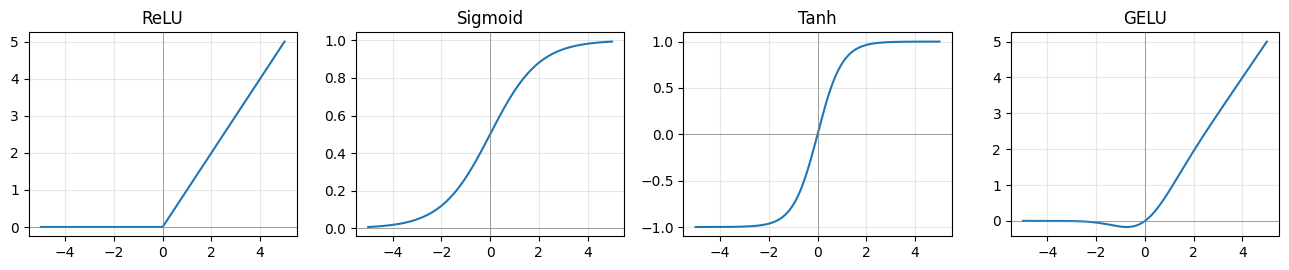

time: 126 ms (started: 2026-08-20 16:58:28 +05:30)


In [24]:
grid = torch.linspace(-5, 5, 200)
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8))
for ax, (name, fn) in zip(axes, [("ReLU", F.relu), ("Sigmoid", torch.sigmoid),
                                 ("Tanh", torch.tanh), ("GELU", F.gelu)]):
    ax.plot(grid, fn(grid)); ax.axhline(0, c="gray", lw=.5); ax.axvline(0, c="gray", lw=.5)
    ax.set_title(name); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Writing a model: subclass `nn.Module`

The contract is two methods:

- **`__init__`** — call `super().__init__()` first (non-negotiable — it sets up the
  bookkeeping), then create your layers as attributes. Assigning an `nn.Module` to `self`
  is what *registers* it, so its parameters show up in `.parameters()` and move with `.to()`.
- **`forward`** — describe the computation on an input batch. No loops over samples: you
  write it as if for one sample, and it runs on the whole batch.

**Call the model, never `forward` directly.** `model(x)` runs hooks and bookkeeping before
delegating to `forward`; `model.forward(x)` skips them. It usually works, until it doesn't.


In [25]:
class TinyNet(nn.Module):
    def __init__(self, in_features=4, hidden=16, n_classes=3):
        super().__init__()                              # ALWAYS first
        self.fc1 = nn.Linear(in_features, hidden)       # assigning to self = registering
        self.fc2 = nn.Linear(hidden, n_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))                         # hidden layer + non-linearity
        x = self.fc2(x)                                 # output layer: RAW SCORES, no softmax
        return x


tiny = TinyNet()
print(tiny)                                             # __repr__ prints the structure for free
print("\noutput shape:", tuple(tiny(torch.randn(10, 4)).shape))

TinyNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

output shape: (10, 3)
time: 1.03 ms (started: 2026-08-20 16:58:28 +05:30)


Notice what the last layer does **not** do: there is no softmax. PyTorch models
output raw, unbounded scores called **logits**, and the loss function applies the softmax
internally (for numerical stability). Adding your own softmax before `nn.CrossEntropyLoss`
is the single most common beginner bug — it does not crash, it just trains badly.


### Parameters: what `.to()` and the optimizer act on

`.parameters()` yields every registered tensor. It is what you hand the optimizer, and it is
what `.to(device)` walks. `named_parameters()` is the same thing with labels — use it when
you want to see where the weight count actually goes.


In [26]:
for name, p in tiny.named_parameters():
    print(f"{name:<12} {str(tuple(p.shape)):<12} {p.numel():>5} values")

total = sum(p.numel() for p in tiny.parameters())
print(f"\ntotal parameters: {total:,}   ( 4*16+16 + 16*3+3 )")

tiny = tiny.to(device)                                   # moves EVERY parameter in one call
print("parameters now on:", next(tiny.parameters()).device)

fc1.weight   (16, 4)         64 values
fc1.bias     (16,)           16 values
fc2.weight   (3, 16)         48 values
fc2.bias     (3,)             3 values

total parameters: 131   ( 4*16+16 + 16*3+3 )
parameters now on: mps:0
time: 3.18 ms (started: 2026-08-20 16:58:28 +05:30)


### `nn.Sequential` — the shorthand

When your `forward` is just "run these in order", `nn.Sequential` writes it for you. It is
the same thing, less typing. Use a subclass when the forward pass has branches, skip
connections, or anything conditional; use `Sequential` for plain stacks.


In [27]:
seq = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),                                          # nn.ReLU() is the LAYER form of F.relu
    nn.Linear(16, 3),
)
print(seq)
print("\nsame output shape:", tuple(seq(torch.randn(10, 4)).shape))
print("same parameter count:", sum(p.numel() for p in seq.parameters()))

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=3, bias=True)
)

same output shape: (10, 3)
same parameter count: 131
time: 798 µs (started: 2026-08-20 16:58:28 +05:30)


### The loss function: `nn.CrossEntropyLoss`

For multi-class classification this is essentially always the answer. Two rules:

1. **It takes raw logits**, shape `(batch, n_classes)`. It applies `log_softmax` itself.
2. **It takes integer class indices**, shape `(batch,)`, dtype `int64` — *not* one-hot
   vectors.

What it measures: how much probability mass you put on the correct class. High score on the
right class → small loss. High score on a wrong class → large loss.


In [28]:
criterion = nn.CrossEntropyLoss()

target = torch.tensor([0])                              # the true class is 0

confident_right = torch.tensor([[3.0, 1.0, 0.0]])       # class 0 wins comfortably
mildly_right    = torch.tensor([[1.0, 0.9, 0.8]])       # class 0 wins, barely
confident_wrong = torch.tensor([[-2.0, 0.5, 3.5]])      # class 2 wins — and it is wrong

for name, logits in [("confident & right", confident_right),
                     ("barely right     ", mildly_right),
                     ("confident & WRONG", confident_wrong)]:
    probs = F.softmax(logits, dim=1)
    print(f"{name} | loss = {criterion(logits, target).item():6.4f} "
          f"| P(class 0) = {probs[0, 0].item():5.3f} | predicted = {logits.argmax(1).item()}")

confident & right | loss = 0.1698 | P(class 0) = 0.844 | predicted = 0
barely right      | loss = 1.0019 | P(class 0) = 0.367 | predicted = 0
confident & WRONG | loss = 5.5525 | P(class 0) = 0.004 | predicted = 2
time: 981 µs (started: 2026-08-20 16:58:28 +05:30)


**A diagnostic worth memorising.** Before training, a network's outputs are
essentially random, so it should assign roughly `1/n_classes` probability to the true class,
giving a loss of $-\ln(1/C) = \ln(C)$:

- 10 classes (MNIST) → `ln(10)` ≈ **2.303**
- 100 classes (CIFAR-100) → `ln(100)` ≈ **4.605**

A freshly initialised layer usually lands a little *above* that value, as below — the point
is the order of magnitude, not the third decimal. If your first-epoch loss starts near it,
your pipeline is wired correctly. If it starts at 15, or at 0.02, something is wrong
*before* training even begins — and you have just saved yourself an hour.


In [29]:
features = torch.randn(512, 64)                          # 512 samples of some hidden features

for n_classes in (10, 100):
    fresh_layer = nn.Linear(64, n_classes)               # a real, freshly initialised output layer
    random_labels = torch.randint(0, n_classes, (512,))
    with torch.no_grad():
        loss = criterion(fresh_layer(features), random_labels).item()
    print(f"untrained loss, {n_classes:>3} classes : {loss:.3f}   (ln {n_classes} = {np.log(n_classes):.3f})")

untrained loss,  10 classes : 2.468   (ln 10 = 2.303)
untrained loss, 100 classes : 4.779   (ln 100 = 4.605)
time: 1.48 ms (started: 2026-08-20 16:58:28 +05:30)


### The optimizer — the same one, now holding a model

You already used an optimizer in Part 2:

```python
optimizer = optim.SGD([x], lr=0.1)          # one tensor
```

Nothing changes here except the list. Swap `[x]` for `model.parameters()` and the same
`zero_grad()` / `step()` pair now updates every weight in the network:

```python
optimizer = optim.SGD(model.parameters(), lr=0.1)     # 109,386 tensors' worth
```

- **`optimizer.zero_grad()`** — clears `.grad` on all of them (because Part 2: gradients accumulate).
- **`optimizer.step()`** — applies the update rule to every parameter.

Note it is `model.parameters()`, **not** `model`. The optimizer wants the tensors, not the
module — and because it holds *references* to them, `step()` mutates the model in place.

| Optimizer | Rule | When |
|---|---|---|
| `SGD(lr=0.1)` | `w -= lr * grad` | the textbook version — exactly Part 2's loop |
| `SGD(lr=0.1, momentum=0.9)` | keeps a running average of past gradients | a strong, cheap default |
| `Adam(lr=1e-3)` | per-parameter adaptive step sizes | works out of the box on almost anything |

Practical advice: start with **`Adam(lr=1e-3)`**. It is the least fussy. We use plain `SGD`
once in Part 5 so you can see the raw version, and Adam thereafter.


In [30]:
demo   = TinyNet().to(device)
optimizer = optim.SGD(demo.parameters(), lr=0.1)         # <- the parameters, not the model

xb = torch.randn(8, 4, device=device)
yb = torch.randint(0, 3, (8,), device=device)

before = demo.fc1.weight.clone()                         # clone: else we watch it change

loss = criterion(demo(xb), yb)                           # forward + loss
optimizer.zero_grad()                                    # clear old gradients
loss.backward()                                          # fill .grad
print("grad of fc1.weight is now populated:", demo.fc1.weight.grad.shape)
optimizer.step()                                         # w -= lr * grad

moved = (demo.fc1.weight - before).abs().max().item()
print(f"largest weight change after one step: {moved:.6f}  <- the model just learned, once")

grad of fc1.weight is now populated: torch.Size([16, 4])
largest weight change after one step: 0.004354  <- the model just learned, once
time: 89.5 ms (started: 2026-08-20 16:58:28 +05:30)


---

### Part 3 recap

- `nn.Module`: layers in `__init__` (assign to `self` to register), maths in `forward`.
- Call `model(x)`, never `model.forward(x)`.
- No softmax on the output — emit **logits**.
- `nn.CrossEntropyLoss(logits, int64_labels)`; untrained loss should be ≈ `ln(n_classes)`.
- `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()`.


```text
P0 setup → P1 tensor vs numpy → P2 autograd → P3 nn.Module → ●P4 DATALOADER →
P5 mnist+mlp → P6 cifar+mlp → P7 cifar+cnn → P8 save+predict
```

# Part 4 — `Dataset` and `DataLoader`: getting data in

The fourth and last piece. MNIST is 60,000 images — small enough to hold in memory, but the
dataset you actually care about at work will not be. PyTorch splits the job in two:

- **`Dataset`** answers *"how many samples are there, and what is sample #i?"* It reads one
  sample at a time, so it never needs the whole dataset in RAM.
- **`DataLoader`** wraps a `Dataset` and does the boring-but-essential work: collecting
  samples into **batches**, **shuffling** each epoch, and loading in background workers so
  the GPU is never sitting idle.

```text
   Dataset               DataLoader                     your loop
   ┌──────────┐          ┌───────────────────┐
   │ [i] -> ( │          │ shuffle indices   │          for x, y in loader:
   │  image,  │ ───────▶ │ fetch 64 samples  │ ───────▶     x: (64, 1, 28, 28)
   │  label ) │          │ stack into tensors│              y: (64,)
   └──────────┘          └───────────────────┘
```

torchvision ships ready-made `Dataset` classes for the standard benchmarks, so today we use
`datasets.MNIST` and `datasets.CIFAR100` rather than writing our own.


### Transforms: from PIL image to normalised tensor

A dataset yields PIL images; a model needs tensors. `transforms.Compose` chains the
conversion steps that run on every sample as it is fetched.

**`ToTensor()`** does three things at once, and all three matter:

```text
  PIL image                        tensor
  (H, W, C) = (28, 28, 1)   ──▶    (C, H, W) = (1, 28, 28)     channels move to the FRONT
  uint8, 0 … 255            ──▶    float32, 0.0 … 1.0          rescaled
```

**`Normalize(mean, std)`** then shifts each channel to roughly zero mean and unit variance:
`(x - mean) / std`. Why bother? Gradient descent behaves much better when inputs are
centred and comparably scaled — the loss surface is rounder, so a single learning rate
works for every weight. The constants below are the published per-channel statistics of
each dataset.


In [31]:
transform = transforms.Compose([
    transforms.ToTensor(),                              # PIL (H,W,C) uint8 -> tensor (C,H,W) float in [0,1]
    transforms.Normalize((0.1307,), (0.3081,)),         # MNIST's own mean/std (1 channel -> 1 value)
])

print(transform)

Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)
time: 294 µs (started: 2026-08-20 16:58:28 +05:30)


### Loading MNIST

70,000 handwritten digits collected from US census workers and high-school students, 28×28
greyscale, 10 classes. It is the "hello world" of computer vision: small, clean, and
solvable to 98% in under a minute — which is exactly why it makes a poor benchmark and a
great teaching set.

Note the `train=True` / `train=False` split. **The test set exists to be looked at once.**
We evaluate on it each epoch here so you can watch the curves, but we never let it influence
a single decision — that is the difference between a test set and a validation set.


In [32]:
train_ds = datasets.MNIST(DATA_ROOT, train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

print("train:", len(train_ds), "| test:", len(test_ds))
print("classes:", train_ds.classes)

img, label = train_ds[0]                                # a Dataset is INDEXABLE — this is __getitem__
print("\none sample -> image", tuple(img.shape), img.dtype, "| label", label, type(label).__name__)
print("pixel range after Normalize: %.2f to %.2f" % (img.min(), img.max()))

train: 60000 | test: 10000
classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']

one sample -> image (1, 28, 28) torch.float32 | label 5 int
pixel range after Normalize: -0.42 to 2.82
time: 12.2 ms (started: 2026-08-20 16:58:28 +05:30)


### `DataLoader`: batching and shuffling

The arguments that matter:

- **`batch_size`** — how many samples per update. Bigger = smoother gradients and better GPU
  utilisation, but more memory and fewer updates per epoch. 32–128 is the normal range.
- **`shuffle=True` for training** — so the model never sees the same order twice and cannot
  learn anything from the ordering. **`shuffle=False` for test**, so your predictions line up
  with your labels when you inspect them.
- **`num_workers`** — background processes that prepare the next batch while the GPU chews
  on the current one. `0` means "do it in the main process", which is what we use here:
  worker processes need a `if __name__ == "__main__"` guard on some platforms and add
  start-up cost that is not worth it for datasets this small.
- **`pin_memory=True`** — only helps CUDA; it stages batches in page-locked memory so the
  CPU→GPU copy can overlap with compute.


In [33]:
BATCH_SIZE = 128
use_pin = torch.cuda.is_available()                     # pinned memory only benefits CUDA

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=use_pin)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=use_pin)

print(f"{len(train_loader)} training batches of {BATCH_SIZE}  (60000 / 128 = 468.75 -> last one is short)")
print(f"{len(test_loader)} test batches")

469 training batches of 128  (60000 / 128 = 468.75 -> last one is short)
79 test batches
time: 599 µs (started: 2026-08-20 16:58:28 +05:30)


Now pull one batch and read the shape carefully, because this layout — **`(N, C, H, W)`**
— is the convention every vision model in PyTorch expects: batch, channels, height, width.
(TensorFlow puts channels last. Half the shape errors people hit when switching frameworks
are this.)


In [34]:
images, labels = next(iter(train_loader))               # iter() then next() = fetch one batch

print("images:", tuple(images.shape), images.dtype, "  <- (N, C, H, W)")
print("labels:", tuple(labels.shape), labels.dtype, "  <- int64, as CrossEntropyLoss wants")
print("first 12 labels:", labels[:12].tolist())
print("pixel range: %.2f to %.2f  (normalised, so negatives are expected)" % (images.min(), images.max()))

images: (128, 1, 28, 28) torch.float32   <- (N, C, H, W)
labels: (128,) torch.int64   <- int64, as CrossEntropyLoss wants
first 12 labels: [1, 4, 2, 7, 6, 4, 5, 7, 8, 9, 1, 4]
pixel range: -0.42 to 2.82  (normalised, so negatives are expected)
time: 6.86 ms (started: 2026-08-20 16:58:28 +05:30)


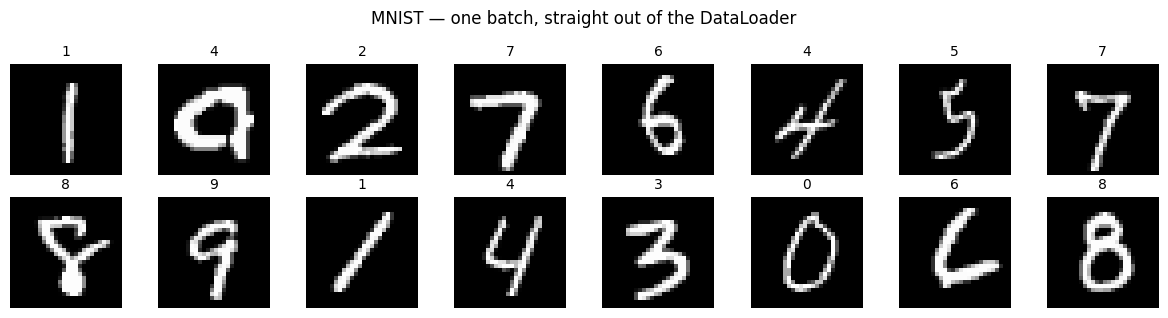

time: 232 ms (started: 2026-08-20 16:58:28 +05:30)


In [35]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, lab in zip(axes.flat, images, labels):
    ax.imshow(img.squeeze(0), cmap="gray")             # squeeze: (1,28,28) -> (28,28) for imshow
    ax.set_title(int(lab), fontsize=10); ax.axis("off")
plt.suptitle("MNIST — one batch, straight out of the DataLoader"); plt.tight_layout(); plt.show()

### Shuffling, seen

A quick sanity check that `shuffle=True` is doing something: the first eight labels of the
first batch differ every epoch for the train loader, and are identical every time for the
test loader.


In [36]:
for epoch in range(3):
    print(f"epoch {epoch} | train (shuffled): {next(iter(train_loader))[1][:8].tolist()}"
          f" | test (fixed): {next(iter(test_loader))[1][:8].tolist()}")

epoch 0 | train (shuffled): [1, 0, 4, 5, 6, 1, 6, 7] | test (fixed): [7, 2, 1, 0, 4, 1, 4, 9]
epoch 1 | train (shuffled): [1, 5, 6, 5, 9, 1, 5, 0] | test (fixed): [7, 2, 1, 0, 4, 1, 4, 9]
epoch 2 | train (shuffled): [3, 3, 1, 2, 9, 1, 8, 6] | test (fixed): [7, 2, 1, 0, 4, 1, 4, 9]
time: 29.2 ms (started: 2026-08-20 16:58:28 +05:30)


---

### Part 4 recap

- `Dataset` = `__len__` + `__getitem__`; `DataLoader` = batching + shuffling + workers.
- `ToTensor()`: HWC uint8 [0,255] → CHW float32 [0,1]. `Normalize()`: centre and scale.
- Images are **`(N, C, H, W)`** in PyTorch.
- `shuffle=True` on train, `shuffle=False` on test.

That is all four pieces. Now we put them in a loop.


```text
P0 setup → P1 tensor vs numpy → P2 autograd → P3 nn.Module → P4 dataloader →
●P5 MNIST+MLP → P6 cifar+mlp → P7 cifar+cnn → P8 save+predict
```

# Part 5 — Your first real network: an MLP on MNIST

A **multi-layer perceptron** is the simplest possible neural network: flatten the input into
a vector, push it through a few fully-connected layers with ReLU in between, and read off
one score per class.

```text
   (N, 1, 28, 28)  ──flatten──▶  (N, 784)  ──▶ 128 ──ReLU──▶ 64 ──ReLU──▶ 10 logits
      an image                   a vector          hidden layers          one score
                                                                          per digit
```

The flatten step is worth pausing on, because it will come back to bite us in Part 6:
turning a 28×28 grid into a 784-long vector **throws away the fact that pixel (5, 5) is next
to pixel (5, 6)**. The network has to rediscover the geometry from scratch. For neat,
centred digits it manages. For photographs it will not.


### Defining the model

`x.view(x.size(0), -1)` is the flatten: keep the batch dimension, collapse everything else.
`x.size(0)` rather than a hard-coded `128` because the last batch of an epoch is short.


In [37]:
class MLP(nn.Module):
    def __init__(self, in_features=28*28, n_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 128)          # 784 -> 128
        self.fc2 = nn.Linear(128, 64)                   # 128 -> 64
        self.fc3 = nn.Linear(64, n_classes)             # 64  -> 10 logits

    def forward(self, x):
        x = x.view(x.size(0), -1)                       # (N,1,28,28) -> (N,784); keep the batch dim
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                                 # no activation here — raw logits
        return x


model = MLP().to(device)
print(model)
print(f"\ntrainable parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

trainable parameters: 109,386
time: 3.92 ms (started: 2026-08-20 16:58:28 +05:30)


### Sanity checks before you train

Two cheap checks catch most wiring mistakes. Do them every time — a failed run costs
minutes, this costs seconds.

1. **Shapes**: one batch in, `(batch, n_classes)` out.
2. **Untrained loss ≈ `ln(n_classes)`** = 2.303 for 10 classes, from Part 3. If it is far
   off, your labels, your output size, or your normalisation is wrong.


In [38]:
criterion = nn.CrossEntropyLoss()

x0, y0 = next(iter(train_loader))
x0, y0 = x0.to(device), y0.to(device)

with torch.no_grad():                                    # no training here, so no graph needed
    logits0 = model(x0)

print("in :", tuple(x0.shape))
print("out:", tuple(logits0.shape), " <- (batch, 10). ✓")
print(f"\nuntrained loss: {criterion(logits0, y0).item():.3f}   (expected ≈ ln 10 = 2.303) ✓")
print(f"untrained accuracy: {(logits0.argmax(1) == y0).float().mean().item():.3f}   (expected ≈ 0.10) ✓")

in : (128, 1, 28, 28)
out: (128, 10)  <- (batch, 10). ✓

untrained loss: 2.312   (expected ≈ ln 10 = 2.303) ✓
untrained accuracy: 0.055   (expected ≈ 0.10) ✓
time: 43 ms (started: 2026-08-20 16:58:28 +05:30)


### The training loop

Here it is — the thing the whole class has been building towards. Read the five starred
lines and compare them with the toy loop in Part 2. They are the same four steps, plus a
loss function.

Two new calls appear, and they are not decoration:

- **`model.train()` / `model.eval()`** flip a flag on every submodule. Dropout and
  BatchNorm behave *differently* in training and inference; forgetting `model.eval()` before
  testing gives you mysteriously bad test numbers. Our MLP has neither layer, so it changes
  nothing here — we write it anyway so the habit is in place for Part 7, where it matters.
- **`torch.no_grad()`** around evaluation — from Part 2: no graph, less memory, faster.

We use plain `SGD` here so that the update really is `w -= lr * grad`, exactly as in Part 2.


In [39]:
optimizer = optim.SGD(model.parameters(), lr=0.1)
EPOCHS = 8


def batch_acc(logits, y):
    # fraction of a batch predicted correctly
    return (logits.argmax(1) == y).float().mean().item()


train_loss_hist, train_acc_hist = [], []
test_loss_hist,  test_acc_hist  = [], []

for epoch in range(1, EPOCHS + 1):

    # ---- train ---------------------------------------------------------
    model.train()                                        # training mode
    run_loss, run_acc = 0.0, 0.0

    for x, y in tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device)                # data must join the model on the device

        logits = model(x)                                # (*) 1. forward
        loss   = criterion(logits, y)                    # (*) 2. how wrong were we?

        optimizer.zero_grad()                            # (*) 3. clear last step's gradients
        loss.backward()                                  # (*) 4. fill every .grad
        optimizer.step()                                 # (*) 5. w -= lr * grad

        run_loss += loss.item()                          # .item() — do NOT accumulate the tensor
        run_acc  += batch_acc(logits, y)

    train_loss = run_loss / len(train_loader)            # mean over batches
    train_acc  = run_acc  / len(train_loader)

    # ---- evaluate ------------------------------------------------------
    model.eval()                                         # inference mode
    v_loss, v_acc = 0.0, 0.0
    with torch.no_grad():                                # no gradients needed
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            v_loss += criterion(logits, y).item()
            v_acc  += batch_acc(logits, y)

    test_loss = v_loss / len(test_loader)
    test_acc  = v_acc  / len(test_loader)

    train_loss_hist.append(train_loss); train_acc_hist.append(train_acc)
    test_loss_hist.append(test_loss);   test_acc_hist.append(test_acc)

    print(f"epoch {epoch:>2}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| test loss {test_loss:.4f} acc {test_acc:.4f}")

print(f"\nfinal MNIST MLP test accuracy: {test_acc_hist[-1]:.2%}")

epoch  1/8 | train loss 0.4074 acc 0.8780 | test loss 0.1806 acc 0.9484


epoch  2/8 | train loss 0.1589 acc 0.9521 | test loss 0.1281 acc 0.9614


epoch  3/8 | train loss 0.1093 acc 0.9674 | test loss 0.1040 acc 0.9676


epoch  4/8 | train loss 0.0831 acc 0.9751 | test loss 0.0960 acc 0.9711


epoch  5/8 | train loss 0.0666 acc 0.9802 | test loss 0.0842 acc 0.9744


epoch  6/8 | train loss 0.0539 acc 0.9836 | test loss 0.0784 acc 0.9765


epoch  7/8 | train loss 0.0440 acc 0.9868 | test loss 0.0758 acc 0.9768


epoch  8/8 | train loss 0.0361 acc 0.9894 | test loss 0.0777 acc 0.9771

final MNIST MLP test accuracy: 97.71%
time: 31.2 s (started: 2026-08-20 16:58:28 +05:30)


### Reading the curves

Two things to look for, every time:

- **Is the training loss going down?** If not, the model is not learning at all — check the
  learning rate, then check that `optimizer.zero_grad()` and `loss.backward()` are both there.
- **Is the test loss tracking the training loss?** When train keeps dropping and test starts
  *rising*, the model has begun memorising the training set instead of generalising. That is
  **overfitting**, and it is the gap between the two lines.


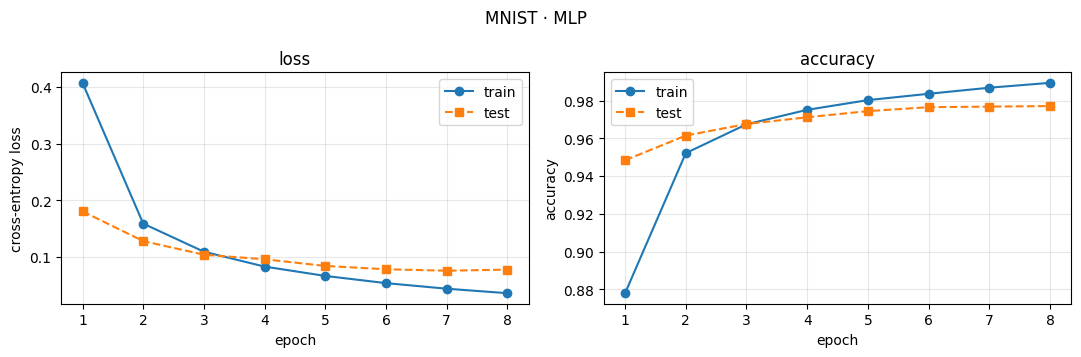

time: 82 ms (started: 2026-08-20 16:59:00 +05:30)


In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
epochs = range(1, len(train_loss_hist) + 1)

ax1.plot(epochs, train_loss_hist, "o-", label="train")
ax1.plot(epochs, test_loss_hist,  "s--", label="test")
ax1.set_xlabel("epoch"); ax1.set_ylabel("cross-entropy loss"); ax1.set_title("loss")
ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(epochs, train_acc_hist, "o-", label="train")
ax2.plot(epochs, test_acc_hist,  "s--", label="test")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.set_title("accuracy")
ax2.legend(); ax2.grid(alpha=.3)

plt.suptitle("MNIST · MLP"); plt.tight_layout(); plt.show()

### Beyond accuracy: which digits does it get wrong?

A single accuracy number hides everything interesting. Collect the predictions over the
whole test set and look at the **per-class** breakdown and the **confusion matrix** — row =
true digit, column = predicted digit, so everything off the diagonal is a mistake.


In [41]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        preds = model(x.to(device)).argmax(1)
        all_preds.append(preds.cpu())                    # back to CPU to collect
        all_labels.append(y)

all_preds  = torch.cat(all_preds).numpy()                # cat: list of batches -> one long tensor
all_labels = torch.cat(all_labels).numpy()

print(classification_report(all_labels, all_preds, digits=3))

              precision    recall  f1-score   support

           0      0.969     0.992     0.980       980
           1      0.990     0.990     0.990      1135
           2      0.982     0.972     0.977      1032
           3      0.968     0.984     0.976      1010
           4      0.961     0.985     0.973       982
           5      0.986     0.961     0.973       892
           6      0.976     0.980     0.978       958
           7      0.979     0.976     0.977      1028
           8      0.972     0.972     0.972       974
           9      0.984     0.953     0.968      1009

    accuracy                          0.977     10000
   macro avg      0.977     0.977     0.977     10000
weighted avg      0.977     0.977     0.977     10000

time: 485 ms (started: 2026-08-20 16:59:00 +05:30)


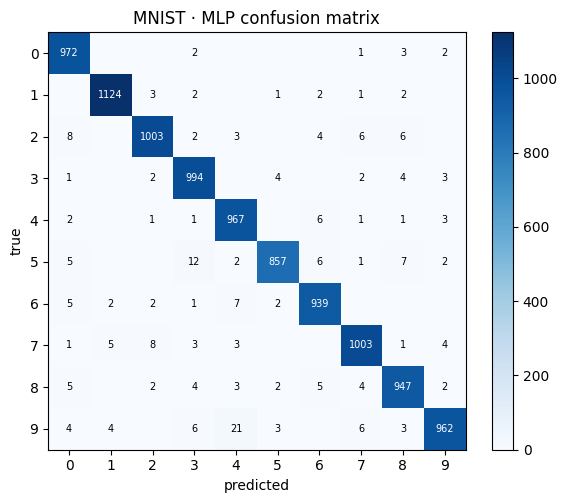

most common mistake: true 9 predicted as 4  (21 times)
time: 80.3 ms (started: 2026-08-20 16:59:00 +05:30)


In [42]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("MNIST · MLP confusion matrix")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

off_diag = cm.copy(); np.fill_diagonal(off_diag, 0)
worst = np.unravel_index(off_diag.argmax(), off_diag.shape)
print(f"most common mistake: true {worst[0]} predicted as {worst[1]}  ({off_diag.max()} times)")

### Look at the actual mistakes

Always do this. Numbers tell you *how much* is wrong; the images tell you *why*. Most of
these will be digits you would struggle with yourself, which is a good sign — it means the
model has learned the task and is failing on genuinely ambiguous input rather than on
something silly.


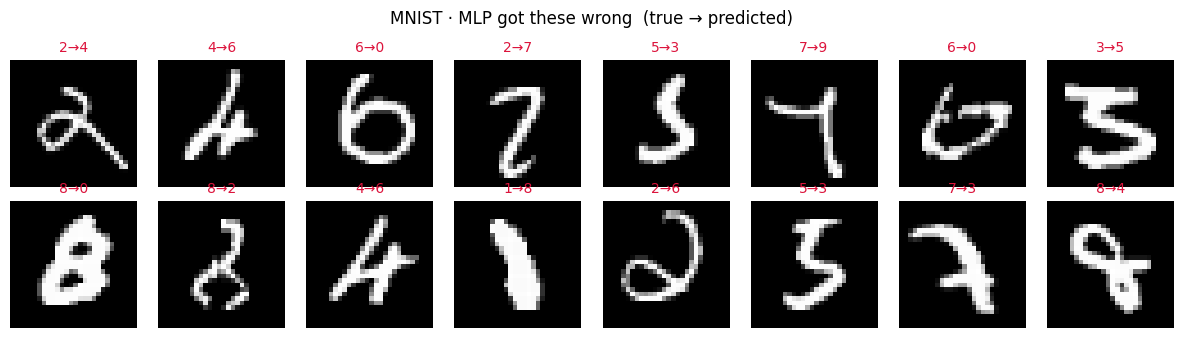

time: 200 ms (started: 2026-08-20 16:59:00 +05:30)


In [43]:
model.eval()
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        preds = model(x.to(device)).argmax(1).cpu()
        miss = preds != y                                # boolean mask over the batch
        wrong_imgs.append(x[miss]); wrong_true.append(y[miss]); wrong_pred.append(preds[miss])
        if sum(len(w) for w in wrong_imgs) >= 16:
            break

wrong_imgs = torch.cat(wrong_imgs); wrong_true = torch.cat(wrong_true); wrong_pred = torch.cat(wrong_pred)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, img, t, p in zip(axes.flat, wrong_imgs, wrong_true, wrong_pred):
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(f"{int(t)}→{int(p)}", fontsize=10, color="crimson"); ax.axis("off")
plt.suptitle("MNIST · MLP got these wrong  (true → predicted)"); plt.tight_layout(); plt.show()

---

### Part 5 recap

~98% on MNIST from three linear layers and eight epochs. All four pieces of PyTorch, in one
loop:

```text
   for x, y in loader:            # P4  DataLoader
       logits = model(x)          # P3  nn.Module  (P1 tensors flowing through)
       loss = criterion(logits, y)# P3  loss
       optimizer.zero_grad()      # P2  gradients accumulate, so clear them
       loss.backward()            # P2  autograd
       optimizer.step()           # P3  optimizer
```

Memorise that block. It does not change for the rest of your career — not for the CNN in
Part 7, not for a transformer, not for a diffusion model.

Now let us find out whether that 98% meant anything.


```text
P0 setup → P1 tensor vs numpy → P2 autograd → P3 nn.Module → P4 dataloader →
P5 mnist+mlp → ●P6 CIFAR+MLP → P7 cifar+cnn → P8 save+predict
```

# Part 6 — Same model, harder data: CIFAR-100

MNIST is a solved problem. Let us hand the exact same architecture something real.

**CIFAR-100**: 60,000 colour photographs, 32×32 pixels, **100 classes** — 500 training
images per class, which is not many. Real objects, real backgrounds, real variation in
pose, lighting and scale.

| | MNIST | CIFAR-100 |
|---|---|---|
| image | 28×28×**1** = 784 values | 32×32×**3** = **3,072** values |
| classes | 10 | **100** |
| train images per class | 6,000 | **500** |
| random-guess accuracy | 10% | **1%** |
| what varies | stroke thickness | pose, lighting, background, scale, colour |

Everything got harder at once: four times the input, ten times the classes, a twelfth of the
examples per class. Watch what that does to the MLP.


### Loading CIFAR-100

Same three lines as MNIST — this is the payoff for the `Dataset`/`DataLoader` abstraction.
Only the normalisation constants change, because now there are three colour channels and
each needs its own mean and standard deviation.


In [44]:
c100_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4865, 0.4409),      # per-CHANNEL mean (R, G, B)
                         (0.2673, 0.2564, 0.2762)),     # per-CHANNEL std
])

c100_train_ds = datasets.CIFAR100(DATA_ROOT, train=True,  download=True, transform=c100_transform)
c100_test_ds  = datasets.CIFAR100(DATA_ROOT, train=False, download=True, transform=c100_transform)

c100_train_loader = DataLoader(c100_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, pin_memory=use_pin)
c100_test_loader  = DataLoader(c100_test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=0, pin_memory=use_pin)

CLASSES = c100_train_ds.classes
print("train:", len(c100_train_ds), "| test:", len(c100_test_ds), "| classes:", len(CLASSES))
print("a few class names:", CLASSES[:12])

img, label = c100_train_ds[0]
print("\none sample -> image", tuple(img.shape), " <- 3 channels now, not 1")

train: 50000 | test: 10000 | classes: 100
a few class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy']

one sample -> image (3, 32, 32)  <- 3 channels now, not 1
time: 1.11 s (started: 2026-08-20 16:59:00 +05:30)


### Look at the data

Always look at the data. These are 32×32 thumbnails — squint and you can just about tell
what they are, which is roughly the difficulty the model faces.

To display them we have to **undo the normalisation** (`x * std + mean`), otherwise
matplotlib gets negative values and clips them into nonsense. And `permute(1, 2, 0)` puts
the channels back at the end, because matplotlib wants `(H, W, C)` while PyTorch stores
`(C, H, W)`.


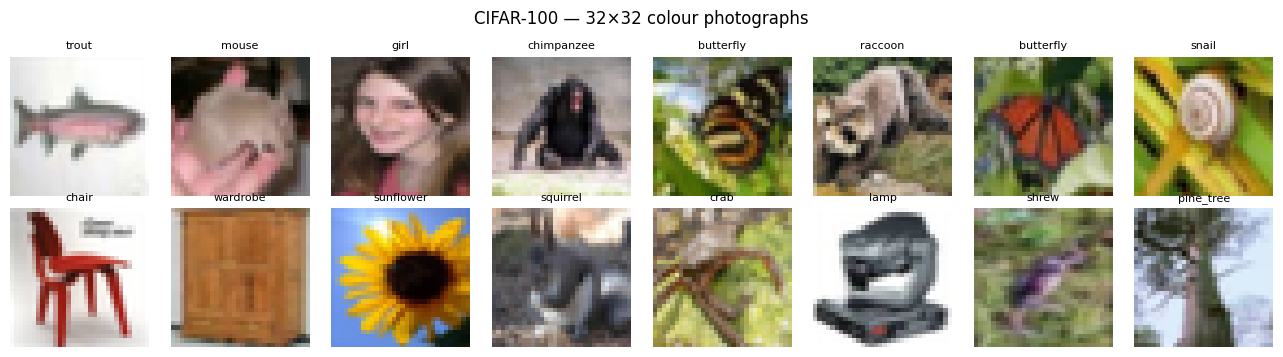

time: 182 ms (started: 2026-08-20 16:59:02 +05:30)


In [45]:
c100_mean = torch.tensor([0.5071, 0.4865, 0.4409]).view(3, 1, 1)   # (3,1,1) so it broadcasts over H,W
c100_std  = torch.tensor([0.2673, 0.2564, 0.2762]).view(3, 1, 1)

images, labels = next(iter(c100_train_loader))

fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for ax, img, lab in zip(axes.flat, images, labels):
    shown = (img * c100_std + c100_mean).clamp(0, 1)     # un-normalise for display
    ax.imshow(shown.permute(1, 2, 0))                    # (C,H,W) -> (H,W,C) for matplotlib
    ax.set_title(CLASSES[lab], fontsize=8); ax.axis("off")
plt.suptitle("CIFAR-100 — 32×32 colour photographs"); plt.tight_layout(); plt.show()

### The same MLP, resized

We do not change the architecture at all. `MLP` was written with `in_features` and
`n_classes` as arguments precisely so we could point it at a different dataset without
touching a line of the model:

- input `3 * 32 * 32 = 3072` instead of `784`
- output `100` instead of `10`

Note what that does to the parameter count. The first layer alone is `3072 × 128`, so this
model is **four times bigger** than the MNIST one — and it is about to do far worse.


In [46]:
c100_mlp = MLP(in_features=3*32*32, n_classes=100).to(device)

print(c100_mlp)
mlp_params = sum(p.numel() for p in c100_mlp.parameters())
print(f"\nMNIST MLP parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"CIFAR-100 MLP parameters : {mlp_params:,}   <- 4x bigger, because the input is 4x bigger")

x0, y0 = next(iter(c100_train_loader))
with torch.no_grad():
    logits0 = c100_mlp(x0.to(device))
print(f"\nshape check: {tuple(x0.shape)} -> {tuple(logits0.shape)} ✓")
print(f"untrained loss: {criterion(logits0, y0.to(device)).item():.3f}  (expected ≈ ln 100 = 4.605) ✓")

MLP(
  (fc1): Linear(in_features=3072, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=100, bias=True)
)

MNIST MLP parameters     : 109,386
CIFAR-100 MLP parameters : 408,100   <- 4x bigger, because the input is 4x bigger



shape check: (128, 3, 32, 32) -> (128, 100) ✓
untrained loss: 4.606  (expected ≈ ln 100 = 4.605) ✓
time: 38.7 ms (started: 2026-08-20 16:59:02 +05:30)


### Train it

Same loop, verbatim. We give it more epochs than MNIST got (20 vs 8) and switch to **Adam**,
so that nobody can claim we handicapped it — this is the MLP getting every reasonable
chance.


In [47]:
c100_mlp_criterion = nn.CrossEntropyLoss()
c100_mlp_optimizer = optim.Adam(c100_mlp.parameters(), lr=1e-3)
C100_EPOCHS = 20

c100_mlp_train_loss_hist, c100_mlp_train_acc_hist = [], []
c100_mlp_test_loss_hist,  c100_mlp_test_acc_hist  = [], []

for epoch in range(1, C100_EPOCHS + 1):

    c100_mlp.train()
    run_loss, run_acc = 0.0, 0.0
    for x, y in tqdm(c100_train_loader, desc=f"epoch {epoch}/{C100_EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device)

        logits = c100_mlp(x)
        loss   = c100_mlp_criterion(logits, y)

        c100_mlp_optimizer.zero_grad()
        loss.backward()
        c100_mlp_optimizer.step()

        run_loss += loss.item(); run_acc += batch_acc(logits, y)

    train_loss = run_loss / len(c100_train_loader)
    train_acc  = run_acc  / len(c100_train_loader)

    c100_mlp.eval()
    v_loss, v_acc = 0.0, 0.0
    with torch.no_grad():
        for x, y in c100_test_loader:
            x, y = x.to(device), y.to(device)
            logits = c100_mlp(x)
            v_loss += c100_mlp_criterion(logits, y).item(); v_acc += batch_acc(logits, y)

    test_loss = v_loss / len(c100_test_loader)
    test_acc  = v_acc  / len(c100_test_loader)

    c100_mlp_train_loss_hist.append(train_loss); c100_mlp_train_acc_hist.append(train_acc)
    c100_mlp_test_loss_hist.append(test_loss);   c100_mlp_test_acc_hist.append(test_acc)

    print(f"epoch {epoch:>2}/{C100_EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| test loss {test_loss:.4f} acc {test_acc:.4f}")

print(f"\nfinal CIFAR-100 MLP test accuracy: {c100_mlp_test_acc_hist[-1]:.2%}"
      f"   (MNIST MLP got {test_acc_hist[-1]:.2%})")

epoch  1/20 | train loss 3.8667 acc 0.1213 | test loss 3.6046 acc 0.1640


epoch  2/20 | train loss 3.4510 acc 0.1876 | test loss 3.4798 acc 0.1805


epoch  3/20 | train loss 3.2772 acc 0.2167 | test loss 3.4205 acc 0.1954


epoch  4/20 | train loss 3.1599 acc 0.2378 | test loss 3.3459 acc 0.2151


epoch  5/20 | train loss 3.0589 acc 0.2563 | test loss 3.3432 acc 0.2155


...

epoch 16/20 | train loss 2.4855 acc 0.3643 | test loss 3.4253 acc 0.2374


epoch 17/20 | train loss 2.4433 acc 0.3745 | test loss 3.5018 acc 0.2263


epoch 18/20 | train loss 2.4200 acc 0.3793 | test loss 3.4736 acc 0.2305


epoch 19/20 | train loss 2.3857 acc 0.3836 | test loss 3.5177 acc 0.2301


epoch 20/20 | train loss 2.3485 acc 0.3914 | test loss 3.5632 acc 0.2275

final CIFAR-100 MLP test accuracy: 22.75%   (MNIST MLP got 97.71%)
time: 1min 37s (started: 2026-08-20 16:59:02 +05:30)


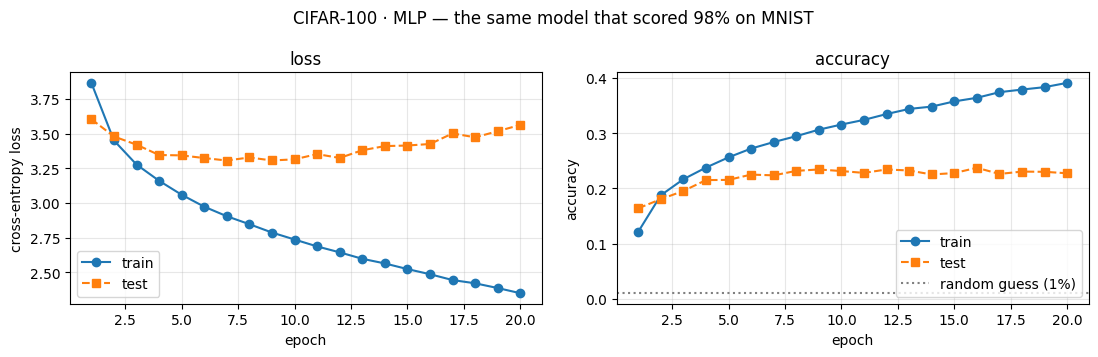

time: 93.4 ms (started: 2026-08-20 17:00:39 +05:30)


In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ep = range(1, len(c100_mlp_train_loss_hist) + 1)

ax1.plot(ep, c100_mlp_train_loss_hist, "o-", label="train")
ax1.plot(ep, c100_mlp_test_loss_hist,  "s--", label="test")
ax1.set_xlabel("epoch"); ax1.set_ylabel("cross-entropy loss"); ax1.set_title("loss")
ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(ep, c100_mlp_train_acc_hist, "o-", label="train")
ax2.plot(ep, c100_mlp_test_acc_hist,  "s--", label="test")
ax2.axhline(0.01, ls=":", c="gray", label="random guess (1%)")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.set_title("accuracy")
ax2.legend(); ax2.grid(alpha=.3)

plt.suptitle("CIFAR-100 · MLP — the same model that scored 98% on MNIST")
plt.tight_layout(); plt.show()

### So what happened?

The training accuracy climbs while the test accuracy stalls — the model is **memorising**
the 50,000 training photographs, not learning what a *bicycle* looks like. It is far better
than the 1% random baseline, so it did learn *something*. But it is nowhere near useful.

There are three reasons, and only the third one is fixable by changing architecture.

**1. Flattening destroys geometry.** `x.view(x.size(0), -1)` turns the image into a
3,072-long list. Input #97 and input #98 are neighbouring pixels, but the network has no way
to know that — they are as related as inputs #97 and #2,900. Every spatial fact has to be
relearned from data.

**2. There is no translation invariance.** A cat in the top-left corner and the same cat in
the bottom-right corner light up *completely different* input neurons, so they are, to the
model, unrelated images. It has to learn "cat" separately for every position.

**3. Dense layers are extravagant.** The first layer alone spends 393,216 weights, one per
(pixel, neuron) pair, and each is used exactly once per image.

Let's demonstrate reason 2, because it is the most striking.


### Measuring the translation problem

Let us not hand-wave this. Take the **entire** test set, roll every image a few pixels
sideways — a change that does not alter what any of the pictures *are* — and re-measure.

`torch.roll(x, shifts=px, dims=3)` shifts along the width axis of an `(N, C, H, W)` batch,
wrapping the pixels that fall off the edge around to the other side.


In [49]:
def shifted_accuracy(net, px):
    # accuracy over the whole test set with every image rolled `px` pixels sideways
    net.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in c100_test_loader:
            x = torch.roll(x, shifts=px, dims=3)             # dims=3 = width of (N,C,H,W)
            correct += (net(x.to(device)).argmax(1).cpu() == y).sum().item()
            total   += y.numel()
    return correct / total


SHIFTS = [0, 1, 2, 4, 8]
mlp_shift_acc = [shifted_accuracy(c100_mlp, px) for px in SHIFTS]

for px, acc in zip(SHIFTS, mlp_shift_acc):
    drop = "" if px == 0 else f"   ({acc/mlp_shift_acc[0] - 1:+.0%} vs unshifted)"
    print(f"shift {px:>2}px | MLP test accuracy {acc:.2%}{drop}")

shift  0px | MLP test accuracy 22.79%
shift  1px | MLP test accuracy 21.61%   (-5% vs unshifted)
shift  2px | MLP test accuracy 19.37%   (-15% vs unshifted)
shift  4px | MLP test accuracy 15.12%   (-34% vs unshifted)
shift  8px | MLP test accuracy 9.66%   (-58% vs unshifted)
time: 3.28 s (started: 2026-08-20 17:00:40 +05:30)


A shift you would not even notice costs the MLP a large slice of its (already poor)
accuracy. Nothing about the *images* got harder — only their alignment changed.

Here is one image it gets right, then gets wrong, purely because it moved. (Some classes
survive the shift fine — a picture of the sea is much the same sea eight pixels to the left.
That is why the number above, measured over all 10,000 test images, is the honest version of
this story and the picture below is only an illustration of it.)


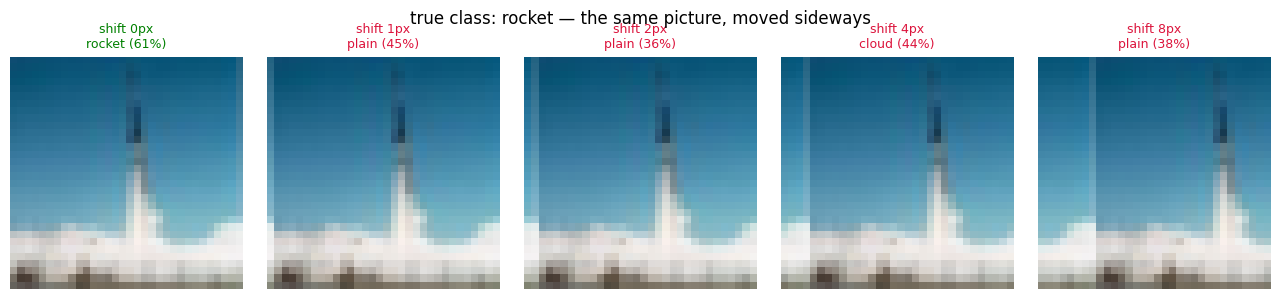

time: 100 ms (started: 2026-08-20 17:00:43 +05:30)


In [50]:
c100_mlp.eval()

# find an image that is classified correctly UNSHIFTED and incorrectly once rolled
with torch.no_grad():
    for xb, yb in c100_test_loader:
        ok_now  = c100_mlp(xb.to(device)).argmax(1).cpu() == yb
        ok_roll = c100_mlp(torch.roll(xb, 8, dims=3).to(device)).argmax(1).cpu() == yb
        breaks = (ok_now & ~ok_roll).nonzero(as_tuple=True)[0]
        if len(breaks):
            idx = breaks[0].item()
            base_img, base_lab = xb[idx], yb[idx].item()
            break

fig, axes = plt.subplots(1, len(SHIFTS), figsize=(13, 3))
for ax, px in zip(axes, SHIFTS):
    shifted = torch.roll(base_img, shifts=px, dims=2)        # single image: width is dim 2
    with torch.no_grad():
        prob, pred = F.softmax(c100_mlp(shifted.unsqueeze(0).to(device)), dim=1).max(1)

    ax.imshow((shifted * c100_std + c100_mean).clamp(0, 1).permute(1, 2, 0))
    ok = pred.item() == base_lab
    ax.set_title(f"shift {px}px\n{CLASSES[pred.item()]} ({prob.item():.0%})",
                 fontsize=9, color="green" if ok else "crimson")
    ax.axis("off")

plt.suptitle(f"true class: {CLASSES[base_lab]} — the same picture, moved sideways")
plt.tight_layout(); plt.show()

No amount of extra epochs fixes that; it is baked into the architecture.

What we want is a layer that:

- looks at **small neighbourhoods** of pixels rather than the whole flattened image,
- uses the **same weights everywhere**, so a feature learned in one corner works in all of
  them,
- and therefore needs **far fewer parameters**.

That layer is the convolution.


```text
P0 setup → P1 tensor vs numpy → P2 autograd → P3 nn.Module → P4 dataloader →
P5 mnist+mlp → P6 cifar+mlp → ●P7 CIFAR+CNN → P8 save+predict
```

# Part 7 — Convolutional networks

A **convolution** slides a small window — a *kernel*, typically 3×3 — across the image. At
each position it multiplies the kernel by the pixels underneath and sums, producing one
output value. Slide it over every position and you get a whole output image, called a
**feature map**.

```text
   input 5×5                 3×3 kernel                output 3×3
   ┌─┬─┬─┬─┬─┐                ┌─┬─┬─┐              ┌─┬─┬─┐
   │▓│▓│▓│ │ │   the kernel   │a│b│c│              │·│ │ │
   ├─┼─┼─┼─┼─┤   sits here,   ├─┼─┼─┤   sum of     ├─┼─┼─┤
   │▓│▓│▓│ │ │   multiplies   │d│e│f│   products   │ │ │ │
   ├─┼─┼─┼─┼─┤   & sums  ──▶  ├─┼─┼─┤   ────────▶  ├─┼─┼─┤
   │▓│▓│▓│ │ │                │g│h│i│              │ │ │ │
   ├─┼─┼─┼─┼─┤                └─┴─┴─┘              └─┴─┴─┘
   │ │ │ │ │ │                                       then the window slides
   ├─┼─┼─┼─┼─┤                 9 weights,            right by 1 and repeats
   │ │ │ │ │ │                 reused at every       across the whole image
   └─┴─┴─┴─┴─┘                 position
```

Three consequences, and they map exactly onto the three failures of Part 6:

1. **Locality** — the kernel only ever sees neighbouring pixels, so spatial structure is
   built into the architecture rather than learned.
2. **Weight sharing** — the same nine numbers are applied everywhere, so a feature learned
   in one corner is automatically detected in every other corner. *Translation invariance,
   for free.*
3. **Parameter economy** — nine weights per kernel, regardless of whether the image is
   32×32 or 4000×3000.


### What a kernel actually does

Convolution is not deep-learning magic — it is the operation behind every image filter you
have ever used. Below we hand-write three classic kernels and apply them with `F.conv2d`.
Nothing is learned here; we are just showing what the operation *is*.

A trained network's first layer discovers kernels much like these on its own, and later
layers combine them into edges → textures → object parts.


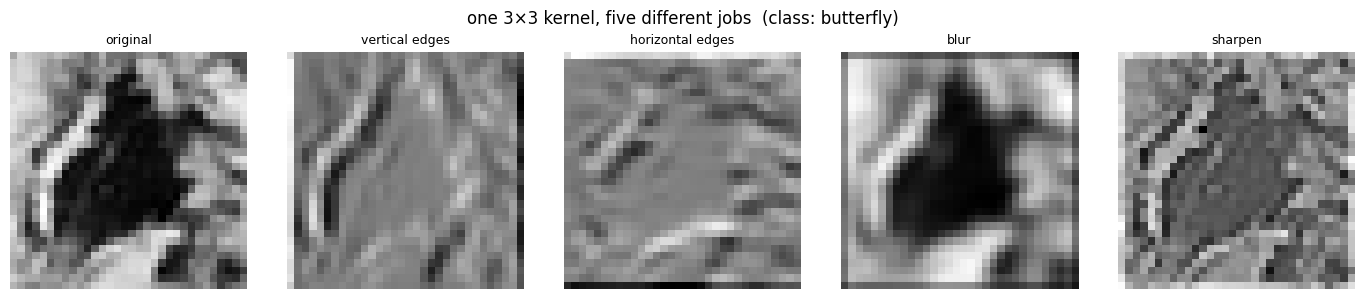

time: 79.9 ms (started: 2026-08-20 17:00:43 +05:30)


In [51]:
sample_img, sample_lab = c100_test_ds[7]
gray = (sample_img * c100_std + c100_mean).clamp(0, 1).mean(0, keepdim=True)   # RGB -> 1 channel

kernels = {
    "original":       None,
    "vertical edges": [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],       # Sobel-x
    "horizontal edges": [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],     # Sobel-y
    "blur":           [[1/9]*3]*3,
    "sharpen":        [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
}

fig, axes = plt.subplots(1, len(kernels), figsize=(14, 3))
for ax, (name, k) in zip(axes, kernels.items()):
    if k is None:
        out = gray
    else:
        kern = torch.tensor(k, dtype=torch.float32).view(1, 1, 3, 3)   # (out_ch, in_ch, kH, kW)
        out = F.conv2d(gray.unsqueeze(0), kern, padding=1).squeeze(0)  # unsqueeze: add batch dim
    ax.imshow(out.squeeze(0), cmap="gray"); ax.set_title(name, fontsize=9); ax.axis("off")

plt.suptitle(f"one 3×3 kernel, five different jobs  (class: {CLASSES[sample_lab]})")
plt.tight_layout(); plt.show()

### `nn.Conv2d` and the shape arithmetic

```python
nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
```

- **`in_channels`** — channels coming in. 3 for an RGB image; for later layers, whatever the
  previous layer emitted.
- **`out_channels`** — how many *different* kernels to learn. Each produces one feature map,
  so this is the depth of the output.
- **`kernel_size`** — 3 is the near-universal default.
- **`padding`** — a border of zeros around the input. `padding=1` with `kernel_size=3` keeps
  the height and width **unchanged**, which is why you will see that pairing everywhere.
- **`stride`** — how far the window jumps. 1 normally.

The output size formula:

$$H_{out} = \left\lfloor \frac{H_{in} + 2 \cdot \text{padding} - \text{kernel}}{\text{stride}} \right\rfloor + 1$$

And the parameter count — this is the punchline of the whole part:

$$\text{params} = (\text{in\_ch} \times k \times k + 1) \times \text{out\_ch}$$

Note what is **absent**: the image size. A conv layer costs the same whether the input is
32×32 or 4000×3000.


In [52]:
conv = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
batch = torch.randn(8, 3, 32, 32)

print("weight shape:", tuple(conv.weight.shape), " <- (out_ch, in_ch, kH, kW) = 32 kernels of 3x3x3")
print("bias shape  :", tuple(conv.bias.shape))
print(f"parameters  : {sum(p.numel() for p in conv.parameters()):,}   ( (3*3*3 + 1) * 32 )")
print("\n(8,3,32,32) ->", tuple(conv(batch).shape), " <- padding=1 preserved 32x32, depth went 3 -> 32")

print("\npadding=0 shrinks by (kernel-1):", tuple(nn.Conv2d(3, 32, 3, padding=0)(batch).shape))
print("stride=2 halves the resolution :", tuple(nn.Conv2d(3, 32, 3, padding=1, stride=2)(batch).shape))

dense_equivalent = 3*32*32 * 32*32*32
print(f"\na Linear layer doing the same input->output mapping would need "
      f"{dense_equivalent:,} weights;\nthe conv needs {sum(p.numel() for p in conv.parameters()):,}.")

weight shape: (32, 3, 3, 3)  <- (out_ch, in_ch, kH, kW) = 32 kernels of 3x3x3
bias shape  : (32,)
parameters  : 896   ( (3*3*3 + 1) * 32 )

(8,3,32,32) -> (8, 32, 32, 32)  <- padding=1 preserved 32x32, depth went 3 -> 32

padding=0 shrinks by (kernel-1): (8, 32, 30, 30)
stride=2 halves the resolution : (8, 32, 16, 16)

a Linear layer doing the same input->output mapping would need 100,663,296 weights;
the conv needs 896.
time: 2.59 ms (started: 2026-08-20 17:00:43 +05:30)


### Pooling: throwing away resolution on purpose

`nn.MaxPool2d(2, 2)` takes each 2×2 block and keeps only the largest value, halving height
and width. Two reasons to want that:

- it **shrinks the tensor** (fewer numbers to process downstream), and
- it adds a little more **shift tolerance** — the maximum in a 2×2 block does not care
  *which* of the four pixels it came from.

The standard pattern is therefore `conv → activation → pool`, repeated: each block halves
the spatial size while doubling the channel count, so the network trades *where* something
is for *what* it is.


In [53]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)
feature_map = torch.randn(8, 32, 32, 32)
print("(8,32,32,32) ->", tuple(pool(feature_map).shape), " <- 32x32 becomes 16x16, channels untouched")

demo_block = torch.tensor([[[[1., 5.], [3., 2.]]]])
print("\nmax-pooling a single 2x2 block:", demo_block.flatten().tolist(), "->",
      pool(demo_block).item())

(8,32,32,32) -> (8, 32, 16, 16)  <- 32x32 becomes 16x16, channels untouched



max-pooling a single 2x2 block: [1.0, 5.0, 3.0, 2.0] -> 5.0
time: 3.05 ms (started: 2026-08-20 17:00:43 +05:30)


### Building the CNN

Three conv blocks, then a small classifier head. Each block: **conv → BatchNorm → ReLU →
conv → BatchNorm → ReLU → pool**, doubling the channels and halving the resolution.

```text
  (N, 3, 32, 32)  ─block1─▶ (N, 32, 16, 16) ─block2─▶ (N, 64, 8, 8) ─block3─▶ (N, 128, 4, 4)
                                                                                   │ flatten
                                                                                   ▼
                                                                      (N, 2048) ─▶ 100 logits
```

Two layers here we have not used before, both one-liners worth knowing because you will see
them in every CNN you read:

- **`nn.BatchNorm2d(c)`** normalises each channel across the batch to zero mean, unit
  variance. It makes deep networks train noticeably faster and more stably. It is one of the
  two layers whose behaviour differs between `.train()` and `.eval()` — which is why those
  calls in the training loop stop being decorative now.
- **`nn.Dropout(p)`** randomly zeroes a fraction `p` of activations *during training only*,
  which stops the network leaning too hard on any one feature. That is our defence against
  the memorisation we watched the MLP do. Also train/eval-dependent.


In [54]:
class CNN(nn.Module):
    def __init__(self, n_classes=100):
        super().__init__()

        self.features = nn.Sequential(
            # block 1:  (N,3,32,32) -> (N,32,16,16)
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # block 2:  (N,32,16,16) -> (N,64,8,8)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # block 3:  (N,64,8,8) -> (N,128,4,4)
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                                # (N,128,4,4) -> (N,2048)
            nn.Dropout(0.3),
            nn.Linear(128 * 4 * 4, n_classes),           # logits, no softmax
        )

    def forward(self, x):
        x = self.features(x)                             # learn WHAT is in the image
        x = self.classifier(x)                           # decide WHICH class that is
        return x


cnn_model = CNN().to(device)
print(cnn_model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

### Trace the shapes yourself

Do not trust the comments — print the shapes. Running one batch through each submodule in
turn is the fastest way to debug a CNN, and it is how you work out what number to put in
that `nn.Linear(128 * 4 * 4, 100)`.


In [55]:
x = torch.randn(4, 3, 32, 32).to(device)
print(f"{'input':<34} {tuple(x.shape)}")

with torch.no_grad():
    for layer in cnn_model.features:
        x = layer(x)
        print(f"{layer.__class__.__name__:<34} {tuple(x.shape)}")
    for layer in cnn_model.classifier:
        x = layer(x)
        print(f"{layer.__class__.__name__:<34} {tuple(x.shape)}")

input                              (4, 3, 32, 32)
Conv2d                             (4, 32, 32, 32)
BatchNorm2d                        (4, 32, 32, 32)
ReLU                               (4, 32, 32, 32)
Conv2d                             (4, 32, 32, 32)
BatchNorm2d                        (4, 32, 32, 32)
ReLU                               (4, 32, 32, 32)
MaxPool2d                          (4, 32, 16, 16)
Conv2d                             (4, 64, 16, 16)
BatchNorm2d                        (4, 64, 16, 16)
ReLU                               (4, 64, 16, 16)
Conv2d                             (4, 64, 16, 16)
BatchNorm2d                        (4, 64, 16, 16)
ReLU                               (4, 64, 16, 16)
MaxPool2d                          (4, 64, 8, 8)
Conv2d                             (4, 128, 8, 8)
BatchNorm2d                        (4, 128, 8, 8)
ReLU                               (4, 128, 8, 8)
MaxPool2d                          (4, 128, 4, 4)
Flatten                            (4,

### The parameter comparison

This is the number to take away from the whole class.


In [56]:
cnn_params = sum(p.numel() for p in cnn_model.parameters())
conv_only  = sum(p.numel() for p in cnn_model.features.parameters())

print(f"CIFAR-100 MLP : {mlp_params:>10,} parameters")
print(f"CIFAR-100 CNN : {cnn_params:>10,} parameters   ({cnn_params/mlp_params:.0%} of the MLP)")
print(f"\n  ...of which only {conv_only:,} do the actual seeing (the convolutions);")
print(f"  the other {cnn_params - conv_only:,} are the single dense classifier at the end.")
print(f"\n  for comparison, the MLP spends {3*32*32*128 + 128:,} on its FIRST LAYER alone.")

with torch.no_grad():
    x0, y0 = next(iter(c100_train_loader))
    logits0 = cnn_model(x0.to(device))
print(f"\nshape check: {tuple(x0.shape)} -> {tuple(logits0.shape)} ✓")
print(f"untrained loss: {criterion(logits0, y0.to(device)).item():.3f}  (expected ≈ 4.605) ✓")

CIFAR-100 MLP :    408,100 parameters
CIFAR-100 CNN :    344,964 parameters   (85% of the MLP)

  ...of which only 140,064 do the actual seeing (the convolutions);
  the other 204,900 are the single dense classifier at the end.

  for comparison, the MLP spends 393,344 on its FIRST LAYER alone.



shape check: (128, 3, 32, 32) -> (128, 100) ✓
untrained loss: 4.830  (expected ≈ 4.605) ✓
time: 73.2 ms (started: 2026-08-20 17:00:43 +05:30)


### Train it — same loop, again

Identical to Parts 5 and 6. Only the model object changed. This is the point of `nn.Module`:
the training code does not care what is inside.


In [57]:
cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)
CNN_EPOCHS = 20

cnn_train_loss_hist, cnn_train_acc_hist = [], []
cnn_test_loss_hist,  cnn_test_acc_hist  = [], []

for epoch in range(1, CNN_EPOCHS + 1):

    cnn_model.train()                                    # NOW this matters: Dropout + BatchNorm
    run_loss, run_acc = 0.0, 0.0
    for x, y in tqdm(c100_train_loader, desc=f"epoch {epoch}/{CNN_EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device)

        logits = cnn_model(x)
        loss   = cnn_criterion(logits, y)

        cnn_optimizer.zero_grad()
        loss.backward()
        cnn_optimizer.step()

        run_loss += loss.item(); run_acc += batch_acc(logits, y)

    train_loss = run_loss / len(c100_train_loader)
    train_acc  = run_acc  / len(c100_train_loader)

    cnn_model.eval()                                     # dropout off, batchnorm uses running stats
    v_loss, v_acc = 0.0, 0.0
    with torch.no_grad():
        for x, y in c100_test_loader:
            x, y = x.to(device), y.to(device)
            logits = cnn_model(x)
            v_loss += cnn_criterion(logits, y).item(); v_acc += batch_acc(logits, y)

    test_loss = v_loss / len(c100_test_loader)
    test_acc  = v_acc  / len(c100_test_loader)

    cnn_train_loss_hist.append(train_loss); cnn_train_acc_hist.append(train_acc)
    cnn_test_loss_hist.append(test_loss);   cnn_test_acc_hist.append(test_acc)

    print(f"epoch {epoch:>2}/{CNN_EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| test loss {test_loss:.4f} acc {test_acc:.4f}")

print(f"\nfinal CIFAR-100 CNN test accuracy: {cnn_test_acc_hist[-1]:.2%}")

epoch  1/20 | train loss 3.3687 acc 0.2018 | test loss 2.7920 acc 0.3039


epoch  2/20 | train loss 2.4347 acc 0.3762 | test loss 2.2561 acc 0.4152


epoch  3/20 | train loss 2.0624 acc 0.4574 | test loss 2.0771 acc 0.4500


epoch  4/20 | train loss 1.8165 acc 0.5125 | test loss 1.9617 acc 0.4817


epoch  5/20 | train loss 1.6280 acc 0.5580 | test loss 1.8194 acc 0.5121


...

epoch 16/20 | train loss 0.7043 acc 0.7874 | test loss 1.8152 acc 0.5565


epoch 17/20 | train loss 0.6655 acc 0.7958 | test loss 1.8320 acc 0.5549


epoch 18/20 | train loss 0.6298 acc 0.8060 | test loss 1.8160 acc 0.5547


epoch 19/20 | train loss 0.5834 acc 0.8187 | test loss 1.8747 acc 0.5564


epoch 20/20 | train loss 0.5638 acc 0.8240 | test loss 1.9568 acc 0.5497

final CIFAR-100 CNN test accuracy: 54.97%
time: 2min 21s (started: 2026-08-20 17:00:43 +05:30)


### The verdict

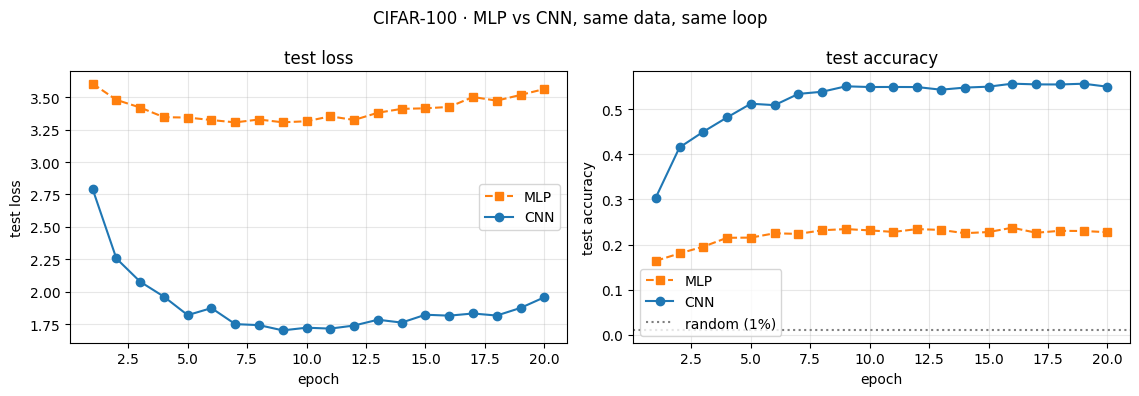

                        params    test acc
random guess                 —      1.00%
MLP                    408,100     22.75%
CNN                    344,964     54.97%

the CNN uses 85% of the parameters and scores 2.4x higher.
time: 91.3 ms (started: 2026-08-20 17:03:04 +05:30)


In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4))
ep_mlp = range(1, len(c100_mlp_test_acc_hist) + 1)
ep_cnn = range(1, len(cnn_test_acc_hist) + 1)

ax1.plot(ep_mlp, c100_mlp_test_loss_hist, "s--", c="tab:orange", label="MLP")
ax1.plot(ep_cnn, cnn_test_loss_hist,      "o-",  c="tab:blue",   label="CNN")
ax1.set_xlabel("epoch"); ax1.set_ylabel("test loss"); ax1.set_title("test loss")
ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(ep_mlp, c100_mlp_test_acc_hist, "s--", c="tab:orange", label="MLP")
ax2.plot(ep_cnn, cnn_test_acc_hist,      "o-",  c="tab:blue",   label="CNN")
ax2.axhline(0.01, ls=":", c="gray", label="random (1%)")
ax2.set_xlabel("epoch"); ax2.set_ylabel("test accuracy"); ax2.set_title("test accuracy")
ax2.legend(); ax2.grid(alpha=.3)

plt.suptitle("CIFAR-100 · MLP vs CNN, same data, same loop"); plt.tight_layout(); plt.show()

print(f"{'':<18}{'params':>12}{'test acc':>12}")
print(f"{'random guess':<18}{'—':>12}{0.01:>11.2%}")
print(f"{'MLP':<18}{mlp_params:>12,}{c100_mlp_test_acc_hist[-1]:>11.2%}")
print(f"{'CNN':<18}{cnn_params:>12,}{cnn_test_acc_hist[-1]:>11.2%}")
print(f"\nthe CNN uses {cnn_params/mlp_params:.0%} of the parameters and scores "
      f"{cnn_test_acc_hist[-1]/c100_mlp_test_acc_hist[-1]:.1f}x higher.")

### Did the shift problem go away?

In Part 6 we rolled the whole test set sideways and watched the MLP lose a chunk of its
accuracy. Run the identical measurement on the CNN. This is the claim "weight sharing buys
translation invariance", checked rather than asserted.


In [59]:
cnn_shift_acc = [shifted_accuracy(cnn_model, px) for px in SHIFTS]

print(f"{'shift':>7} | {'MLP':>18} | {'CNN':>18}")
print("-" * 51)
for px, m_acc, c_acc in zip(SHIFTS, mlp_shift_acc, cnn_shift_acc):
    m_rel = "" if px == 0 else f" ({m_acc/mlp_shift_acc[0] - 1:+.0%})"
    c_rel = "" if px == 0 else f" ({c_acc/cnn_shift_acc[0] - 1:+.0%})"
    print(f"{px:>5}px | {m_acc:>9.2%}{m_rel:>9} | {c_acc:>9.2%}{c_rel:>9}")

print(f"\nat an 8px shift the MLP keeps {mlp_shift_acc[-1]/mlp_shift_acc[0]:.0%} of its accuracy, "
      f"the CNN keeps {cnn_shift_acc[-1]/cnn_shift_acc[0]:.0%}.")

  shift |                MLP |                CNN
---------------------------------------------------
    0px |    22.79%          |    55.10%         
    1px |    21.61%    (-5%) |    53.69%    (-3%)
    2px |    19.37%   (-15%) |    51.41%    (-7%)
    4px |    15.12%   (-34%) |    45.37%   (-18%)
    8px |     9.66%   (-58%) |    30.52%   (-45%)

at an 8px shift the MLP keeps 42% of its accuracy, the CNN keeps 55%.
time: 4.39 s (started: 2026-08-20 17:03:04 +05:30)


The CNN degrades roughly **half as fast** as the MLP at every shift — the weight sharing is
doing real work. But look again: it still degrades. Two honest caveats worth taking away,
because a lot of teaching material skips them:

- Convolution gives **equivariance**, not invariance: shift the input and the feature maps
  shift with it. It is only the pooling (and the final flatten) that convert any of that into
  genuine position-independence, and they do so imperfectly.
- An 8-pixel roll on a 32-pixel image moves a **quarter of the frame**, and `torch.roll`
  wraps the content around, slicing objects across the edge. That is a brutal test, not a
  realistic one.

The practical fix is not a cleverer architecture — it is to *show the model shifted images
during training*. That is exactly what `RandomCrop(32, padding=4)` does, and it is the first
item on the "where to go next" list at the end of this notebook.


### Where the remaining errors are

100 classes is a lot to summarise, so instead of a 100×100 confusion matrix, look at the
best and worst classes. The pattern is usually intuitive: distinctive, consistently-shaped
things do well; fine-grained categories that look alike at 32×32 do badly.


In [60]:
cnn_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in c100_test_loader:
        all_preds.append(cnn_model(x.to(device)).argmax(1).cpu()); all_labels.append(y)
all_preds = torch.cat(all_preds).numpy(); all_labels = torch.cat(all_labels).numpy()

per_class = confusion_matrix(all_labels, all_preds).diagonal() / 100.0   # 100 test images per class
order = np.argsort(per_class)

print("hardest 10 classes")
for i in order[:10]:
    print(f"  {CLASSES[i]:<16} {per_class[i]:.0%}")
print("\neasiest 10 classes")
for i in order[-10:][::-1]:
    print(f"  {CLASSES[i]:<16} {per_class[i]:.0%}")

hardest 10 classes
  seal             10%
  rabbit           25%
  woman            26%
  butterfly        27%
  lizard           28%
  squirrel         29%
  turtle           29%
  boy              29%
  ray              30%
  tulip            32%

easiest 10 classes
  motorcycle       93%
  wardrobe         85%
  plain            84%
  sea              78%
  road             78%
  rocket           77%
  chimpanzee       77%
  streetcar        75%
  sunflower        75%
  chair            75%
time: 844 ms (started: 2026-08-20 17:03:09 +05:30)


### What the first layer learned

Earlier in this part we hand-wrote an edge detector and watched it fire on a butterfly. The
network was never told about edges — so what did its 32 kernels actually end up detecting?

Printing the kernels themselves is a waste of time: a 3×3×3 kernel is 27 numbers, and as a
picture it is three coloured pixels. What you *can* read is their **output** — the 32 feature
maps produced when a real image passes through `features[0]`. Bright regions are where that
kernel found what it is looking for. Several of them are recognisably edge and
colour-contrast detectors, discovered from nothing but the loss signal.


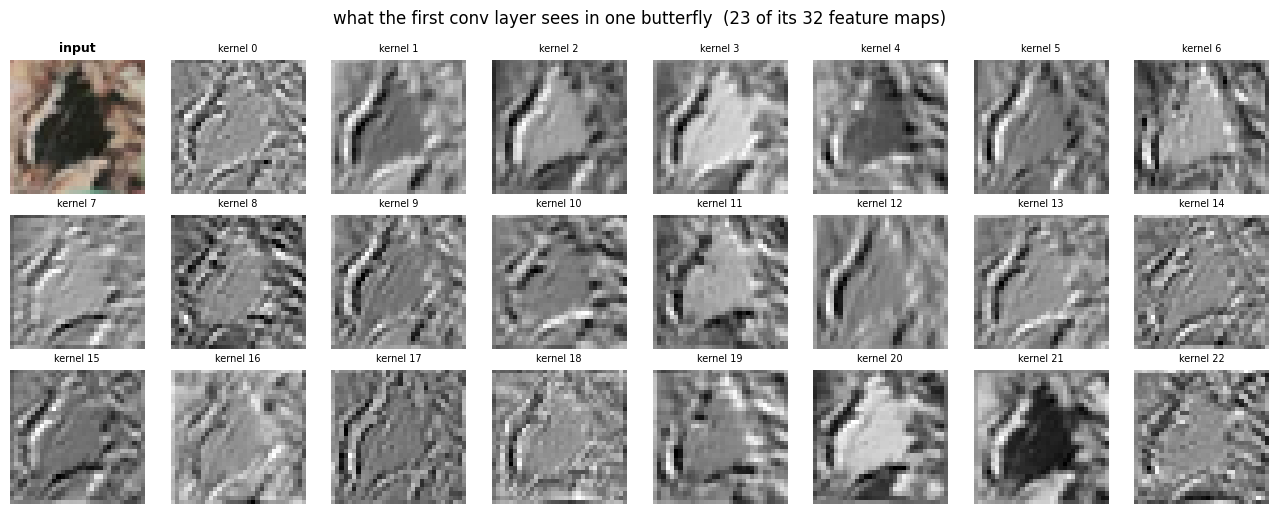

time: 279 ms (started: 2026-08-20 17:03:10 +05:30)


In [61]:
cnn_model.eval()
with torch.no_grad():
    fmaps = cnn_model.features[0](sample_img.unsqueeze(0).to(device))[0].cpu()   # (32, 32, 32)

fig, axes = plt.subplots(3, 8, figsize=(13, 5.2))

axes.flat[0].imshow((sample_img * c100_std + c100_mean).clamp(0, 1).permute(1, 2, 0))
axes.flat[0].set_title("input", fontsize=9, weight="bold"); axes.flat[0].axis("off")

for k, (ax, fmap) in enumerate(zip(axes.flat[1:], fmaps)):
    ax.imshow(fmap, cmap="gray"); ax.set_title(f"kernel {k}", fontsize=7); ax.axis("off")

plt.suptitle(f"what the first conv layer sees in one {CLASSES[sample_lab]}  "
             f"(23 of its 32 feature maps)")
plt.tight_layout(); plt.show()

---

### Part 7 recap

- A convolution slides a small kernel over the image: **locality**, **weight sharing**,
  **few parameters**.
- `padding=1` with `kernel_size=3` keeps the spatial size; `MaxPool2d(2,2)` halves it.
- The standard shape: conv blocks that halve resolution and double channels, then a small
  dense head.
- `model.train()` / `model.eval()` genuinely matter once Dropout and BatchNorm are present.
- Same data, same training loop, **fewer** parameters — and several times the accuracy.
  The convolutional part is barely a third of what the MLP spent on its first layer alone.
  Architecture is not a detail.


```text
P0 setup → P1 tensor vs numpy → P2 autograd → P3 nn.Module → P4 dataloader →
P5 mnist+mlp → P6 cifar+mlp → P7 cifar+cnn → ●P8 SAVE+PREDICT
```

# Part 8 — Saving, loading, and predicting on one image

A model that only exists inside a running notebook is not much use. The last piece is
getting the weights onto disk and back, and then running a prediction on a single image the
way a served application would.


### `state_dict` — a model's weights, as a plain dictionary

`model.state_dict()` returns an ordered dict mapping parameter names to tensors. That is
*all* a trained model is: some numbers and the names they belong to. The architecture lives
in your code, not in the file.

**Save the `state_dict`, not the model object.** `torch.save(model)` pickles the Python
class itself, which then breaks the moment you rename the file it was defined in.


In [62]:
sd = cnn_model.state_dict()

print(f"{len(sd)} entries. The first few:\n")
for k, v in list(sd.items())[:6]:
    print(f"  {k:<28} {str(tuple(v.shape)):<20} {v.dtype}")

total_bytes = sum(v.numel() * v.element_size() for v in sd.values())
print(f"\ntotal size on disk ≈ {total_bytes/1e6:.1f} MB   ({sum(v.numel() for v in sd.values()):,} numbers)")

37 entries. The first few:

  features.0.weight            (32, 3, 3, 3)        torch.float32
  features.0.bias              (32,)                torch.float32
  features.1.weight            (32,)                torch.float32
  features.1.bias              (32,)                torch.float32
  features.1.running_mean      (32,)                torch.float32
  features.1.running_var       (32,)                torch.float32

total size on disk ≈ 1.4 MB   (345,609 numbers)
time: 749 µs (started: 2026-08-20 17:03:10 +05:30)


### Save and reload

`weights_only=True` on load tells PyTorch to refuse anything but tensors, which stops a
malicious checkpoint from executing code when you open it. It is the default in recent
PyTorch and you should never turn it off for a file you did not create.

The reload sequence is always the same three steps:

1. **construct the architecture** (`CNN()`) — the file has no idea what shape the model is,
2. **load the weights** into it,
3. **`.eval()`** — because you are about to do inference, and Dropout must be off.


In [63]:
CNN_PATH = "cifar100_cnn.pth"
torch.save(cnn_model.state_dict(), CNN_PATH)
print(f"saved -> {CNN_PATH}  ({os.path.getsize(CNN_PATH)/1e6:.1f} MB on disk)")

cnn_reload = CNN().to(device)                                  # 1. same architecture
cnn_reload.load_state_dict(torch.load(CNN_PATH, weights_only=True))   # 2. weights
cnn_reload.eval()                                              # 3. inference mode

# verify: the reloaded model must agree with the original, exactly
with torch.no_grad():
    x, y = next(iter(c100_test_loader))
    x = x.to(device)
    same = torch.allclose(cnn_model(x), cnn_reload(x), atol=1e-6)
print("reloaded model produces identical logits:", same)

saved -> cifar100_cnn.pth  (1.4 MB on disk)
reloaded model produces identical logits: True
time: 85.1 ms (started: 2026-08-20 17:03:10 +05:30)


A checkpoint you can *resume* from needs more than the weights — it needs the
optimizer's internal state (Adam keeps running averages per parameter) and the epoch number.
The convention is to save a plain dict:


In [64]:
torch.save({
    "epoch": CNN_EPOCHS,
    "model_state_dict": cnn_model.state_dict(),
    "optimizer_state_dict": cnn_optimizer.state_dict(),   # Adam's momentum buffers
    "test_acc": cnn_test_acc_hist[-1],
}, "cifar100_checkpoint.pth")

ckpt = torch.load("cifar100_checkpoint.pth", weights_only=True)
print("checkpoint keys:", list(ckpt.keys()))
print(f"resuming from epoch {ckpt['epoch']} with test accuracy {ckpt['test_acc']:.2%}")

checkpoint keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'test_acc']
resuming from epoch 20 with test accuracy 54.97%
time: 54.4 ms (started: 2026-08-20 17:03:10 +05:30)


### Predicting on a single image

The three things people forget, in the order they forget them:

1. **`model.eval()`** — otherwise Dropout is still randomly deleting activations and your
   prediction changes every time you run it.
2. **`unsqueeze(0)`** — models take a *batch*. One image `(3,32,32)` must become `(1,3,32,32)`.
3. **`torch.no_grad()`** — you are not training; do not build a graph.

And one more: the model outputs **logits**. To show a human a confidence you must apply
`softmax` yourself — the loss function was doing it for you during training, and there is no
loss function at inference time.


In [65]:
cnn_reload.eval()                                    # 1. inference mode

img, true_label = c100_test_ds[42]                   # one image: (3, 32, 32)
batch_of_one = img.unsqueeze(0).to(device)           # 2. -> (1, 3, 32, 32)

with torch.no_grad():                                # 3. no graph
    logits = cnn_reload(batch_of_one)

probs = F.softmax(logits, dim=1)                     # logits -> probabilities
top5_prob, top5_idx = probs.topk(5, dim=1)

print(f"true class: {CLASSES[true_label]}\n")
print("model's top 5:")
for rank, (p, i) in enumerate(zip(top5_prob[0], top5_idx[0]), 1):
    mark = " <-- correct" if i.item() == true_label else ""
    print(f"  {rank}. {CLASSES[i]:<16} {p.item():6.2%}{mark}")

true class: mountain

model's top 5:


  1. whale            80.11%
  2. keyboard         11.65%
  3. mountain          2.11% <-- correct
  4. train             1.46%
  5. couch             1.08%
time: 50.1 ms (started: 2026-08-20 17:03:10 +05:30)


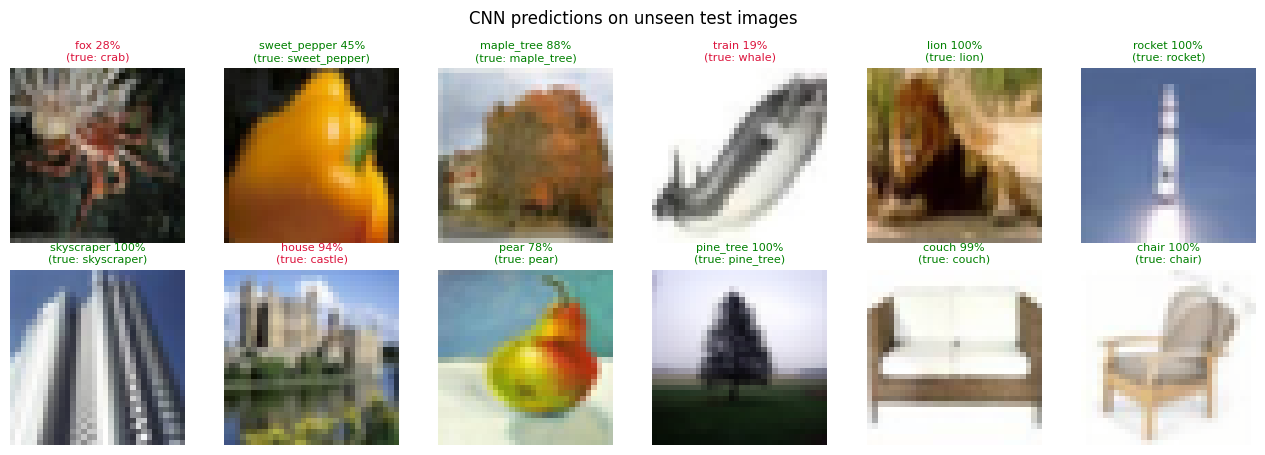

time: 178 ms (started: 2026-08-20 17:03:10 +05:30)


In [66]:
fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))

with torch.no_grad():
    for ax, idx in zip(axes.flat, range(100, 112)):
        img, true_label = c100_test_ds[idx]
        probs = F.softmax(cnn_reload(img.unsqueeze(0).to(device)), dim=1)[0]
        conf, pred = probs.max(0)

        ax.imshow((img * c100_std + c100_mean).clamp(0, 1).permute(1, 2, 0))
        ok = pred.item() == true_label
        ax.set_title(f"{CLASSES[pred]} {conf:.0%}\n(true: {CLASSES[true_label]})",
                     fontsize=8, color="green" if ok else "crimson")
        ax.axis("off")

plt.suptitle("CNN predictions on unseen test images"); plt.tight_layout(); plt.show()

---

## Wrap-up

### What we did

```text
   P1  tensor      →  n-dim array, on any device, that can track gradients
   P2  autograd    →  .backward() fills .grad; that IS how learning happens
   P3  nn.Module   →  layers hold weights; loss scores them; optimizer updates them
   P4  DataLoader  →  shuffled, batched, on time
   ────────────────────────────────────────────────────────────────────────
   P5  MNIST     + MLP  →  ~98%   easy data hides a bad architecture
   P6  CIFAR-100 + MLP  →  ~22%   flattening throws away the picture
   P7  CIFAR-100 + CNN  →  ~55%   fewer parameters, several times the score
   P8  save → load → predict
```

### The loop, one more time

```python
for x, y in loader:
    x, y = x.to(device), y.to(device)
    logits = model(x)
    loss   = criterion(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
```

Six lines. Every PyTorch training script on GitHub is this, plus logging.

### The errors you will actually hit, and what they mean

| Message | Cause | Fix |
|---|---|---|
| `Expected all tensors to be on the same device` | model on GPU, data on CPU | `x, y = x.to(device), y.to(device)` |
| `mat1 and mat2 shapes cannot be multiplied` | wrong `in_features` on a `Linear` | print the shape going in |
| `expected scalar type Long but found Float` | labels are `float32` | `y.long()` |
| loss is `nan` | learning rate too high | divide the lr by 10 |
| loss flat at `ln(n_classes)` | nothing is updating | is `optimizer.step()` there? did you pass `model.parameters()`? |
| loss goes down but accuracy is stuck | added a `softmax` before `CrossEntropyLoss` | delete it — emit logits |
| test accuracy much worse than expected | forgot `model.eval()` | call it before evaluating |
| `element 0 of tensors does not require grad` | forward ran inside `no_grad()` | only wrap *evaluation* |
| memory grows every epoch | accumulating loss tensors | `+= loss.item()` |

### The checklist before every training run

1. Print one batch's shapes.
2. Check the untrained loss is ≈ `ln(n_classes)`.
3. Overfit a single batch on purpose — if the model cannot reach ~100% on 128 images, it
   will never learn the full set, and you have a bug rather than a tuning problem.
4. *Then* start the real run.

### Where to go next

- **Data augmentation** — `RandomCrop(32, padding=4)` and `RandomHorizontalFlip()` alone
  take this exact CNN several points higher, for zero extra parameters.
- **Learning-rate schedules** — `CosineAnnealingLR` is a free point or two.
- **Transfer learning** — a ResNet pretrained on ImageNet, fine-tuned on CIFAR-100, beats
  everything here in a fraction of the epochs. It is what you would actually reach for at
  work.
- **`torchvision.models`** — ResNet, EfficientNet, ViT, pretrained, one line each.

All of that is a variation on the six lines above. You already know PyTorch.
